# Capstone Project

In [71]:
%reset -f

In [72]:
# IMPORTING LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.optimize import minimize
from sklearn.gaussian_process.kernels import Matern
import matplotlib.colors as mcolors



np.random.seed(42)


In [73]:
# LOADING FUNCTION VALUES
def load_function(fn_num):
    X_read = np.load(f'initial_data_3/function_{fn_num}/initial_inputs.npy')
    y_read = np.load(f'initial_data_3/function_{fn_num}/initial_outputs.npy')
    cols = [f'x{i+1}' for i in range(X_read.shape[1])]
    X = pd.DataFrame(X_read, columns=cols)
    y = pd.Series(y_read, name='y')
    return X, y

X1, y1 = load_function(1)
X2, y2 = load_function(2)
X3, y3 = load_function(3)
X4, y4 = load_function(4)
X5, y5 = load_function(5)
X6, y6 = load_function(6)
X7, y7 = load_function(7)
X8, y8 = load_function(8)

all_X = [X1, X2, X3, X4, X5, X6, X7, X8]
all_y = [y1, y2, y3, y4, y5, y6, y7, y8]

In [74]:

# ── Acquisition functions ────────────────────────────────────────────────────

def acq_PI(mu, sigma, y_max, y_vals, xi_frac=0.01):
    y_vals = np.asarray(y_vals).ravel()
    xi = float(xi_frac * max(y_vals.std(), 1e-6))
    z = (mu - y_max - xi) / (sigma + 1e-9)
    return norm.cdf(z)

def acq_EI(mu, sigma, y_max, y_vals, xi_frac=0.01):
    y_vals = np.asarray(y_vals).ravel()
    xi = float(xi_frac * max(y_vals.std(), 1e-6))
    z = (mu - y_max - xi) / (sigma + 1e-9)
    ei = (mu - y_max - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma < 1e-10] = 0
    return ei

def acq_UCB(mu, sigma, y_max, y_vals, t, d=1, delta=0.5):
    beta = min(np.sqrt(2 * np.log(d * t**2 * np.pi**2 / (6 * delta))), 2.0)
    return mu + beta * sigma


# ── Bayesian optimisation ────────────────────────────────────────────────────

def run_bo(fn_num, n_candidates=2000):
    X = all_X[fn_num - 1].values
    Y = all_y[fn_num - 1].values
    n_dim = X.shape[1]
    dim_cols = all_X[fn_num - 1].columns.tolist()
    y_max = Y.max()

    kernel = Matern(
        length_scale=np.ones(n_dim),
        length_scale_bounds=(1e-3, 100.0),
        nu=2.5
    )
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-6,
        n_restarts_optimizer=max(5, 2 * n_dim),
        normalize_y=True
    )
    gp.fit(X, Y)

    candidates = np.random.uniform(1e-6, 0.999999, size=(n_candidates, n_dim))
    mu, sigma = gp.predict(candidates, return_std=True)

    acq_results = {
        'EI':  candidates[np.argmax(acq_EI(mu, sigma, y_max, Y))],
        'UCB': candidates[np.argmax(acq_UCB(mu, sigma, y_max, Y, t=len(Y), d=n_dim))],
        'PI':  candidates[np.argmax(acq_PI(mu, sigma, y_max, Y))],
    }

    rows = []
    for acq_name, x_next in acq_results.items():
        pred_y = float(gp.predict(x_next.reshape(1, -1))[0])
        row = {
            'function':     fn_num,
            'dimensions':   n_dim,
            'acquisition':  acq_name,
            'predicted_y':  round(pred_y, 6),
            'y_max_so_far': round(float(y_max), 6),
            'submission':   '-'.join([f'{v:.6f}' for v in x_next]),
        }
        for i, col in enumerate(dim_cols):
            row[f'{col}_suggested'] = round(float(x_next[i]), 6)
        rows.append(row)

    return pd.DataFrame(rows), gp

In [75]:
# DEFINING PLOTTING FUNCTION 

def plot_function(fn_num, df_all=None):
    X        = all_X[fn_num - 1]
    y        = all_y[fn_num - 1]
    n_dim    = X.shape[1]
    dim_cols = X.columns.tolist()

    n_cols = min(4, n_dim)
    n_rows = int(np.ceil(n_dim / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 4 * n_rows),
                             squeeze=False)

    y_rank = y.rank(pct=True)

    # ── Pre-fetch BO suggestions for this function
    acq_styles = {
        'EI':  dict(color='green',  linestyle='--', linewidth=2.5, zorder=5),
        'UCB': dict(color='purple', linestyle='-.',  linewidth=2.5, zorder=5),
        'PI':  dict(color='red',    linestyle=':',   linewidth=2.5, zorder=5),
    }
    fn_suggestions = None
    if df_all is not None:
        fn_suggestions = df_all[df_all['function'] == fn_num]
        print(f"F{fn_num}: {len(fn_suggestions)} suggestion rows, cols: {fn_suggestions.columns.tolist()}")

    for idx, col in enumerate(dim_cols):
        row, col_idx = divmod(idx, n_cols)
        ax = axes[row][col_idx]

        ax.scatter(X[col], y,
                   c=y_rank, cmap='rainbow',
                   s=60, edgecolors='k', linewidths=0.3, zorder=2)

        z = np.polyfit(X[col], y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(X[col].min(), X[col].max(), 100)
        ax.plot(x_line, p(x_line), color='black', linewidth=1.5,
                linestyle='--', alpha=0.7, zorder=3)

        corr = X[col].corr(y)
        ax.set_title(f'{col} vs y  |  r={corr:.2f}', fontsize=10, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('y')
        ax.grid(True, alpha=0.3)
        ax.scatter(X[col], y,
                   c=y_rank, cmap='rainbow',
                   s=60, edgecolors='k', linewidths=0.3, zorder=2)

        # ── Last submitted point (star marker)
        ax.scatter(X[col].iloc[-1], y.iloc[-1],
                   marker='*', s=300, color='gold',
                   edgecolors='black', linewidths=0.5,
                   zorder=6, label=f'last (y={y.iloc[-1]:.3e})')
        ax.legend(fontsize=7, loc='upper right')

        # ── Draw vertical lines inline — no separate function needed
        if fn_suggestions is not None:
            suggested_col = f'{col}_suggested'
            if suggested_col in fn_suggestions.columns:
                for _, srow in fn_suggestions.iterrows():
                    x_val = srow[suggested_col]
                    acq   = srow['acquisition']
                    ax.axvline(x=x_val, **acq_styles.get(acq, {}),
                               label=f"{acq}={x_val:.3f}")
                ax.legend(fontsize=7, loc='upper right')

    for idx in range(n_dim, n_rows * n_cols):
        row, col_idx = divmod(idx, n_cols)
        axes[row][col_idx].set_visible(False)

    fig.subplots_adjust(right=0.82)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap='rainbow',
                                norm=plt.Normalize(vmin=y.min(), vmax=y.max()))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label='y value')

    plt.suptitle(f'Function {fn_num} | {n_dim}D — Marginal Plots (x_i vs y)\n'
                 f'r = Pearson correlation | dashed = linear trend',
                 fontweight='bold', fontsize=12)
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()


In [76]:
# RUN BO ON ALL FUNCTIONS

def get_n_candidates(n_dim):
    """Scale candidate pool with dimensionality."""
    return {1: 1000, 2: 2000, 3: 3000, 4: 5000, 5: 7500, 6: 10000, 7: 15000, 8: 20000}.get(n_dim, 2000)

all_suggestions = []
gps = {}

for fn in range(1, 9):
    n_dim = all_X[fn - 1].shape[1]
    n_cand = get_n_candidates(n_dim)
    df_sugg, gp = run_bo(fn, n_candidates=n_cand)
    all_suggestions.append(df_sugg)
    gps[fn] = gp
    print(f'F{fn} (d={n_dim}, n_cand={n_cand}) done. Fitted kernel: {gp.kernel_}')

df_all = pd.concat(all_suggestions, ignore_index=True)
print(f'\nTotal rows: {len(df_all)} (8 functions x 3 acquisition functions)')
print(df_all[['function','dimensions','acquisition','y_max_so_far','predicted_y']].to_string(index=False))

F1 (d=2, n_cand=2000) done. Fitted kernel: Matern(length_scale=[0.0439, 0.0859], nu=2.5)
F2 (d=2, n_cand=2000) done. Fitted kernel: Matern(length_scale=[0.0821, 0.0222], nu=2.5)
F3 (d=3, n_cand=3000) done. Fitted kernel: Matern(length_scale=[0.472, 0.00705, 100], nu=2.5)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


F4 (d=4, n_cand=5000) done. Fitted kernel: Matern(length_scale=[0.761, 0.621, 0.81, 0.725], nu=2.5)
F5 (d=4, n_cand=5000) done. Fitted kernel: Matern(length_scale=[100, 11.6, 0.587, 0.33], nu=2.5)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


F6 (d=5, n_cand=7500) done. Fitted kernel: Matern(length_scale=[0.471, 0.872, 0.981, 0.955, 0.888], nu=2.5)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


F7 (d=6, n_cand=10000) done. Fitted kernel: Matern(length_scale=[0.122, 100, 100, 0.701, 0.451, 0.453], nu=2.5)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


F8 (d=8, n_cand=20000) done. Fitted kernel: Matern(length_scale=[1.21, 1.74, 0.855, 2.17, 4.33, 100, 1.31, 100], nu=2.5)

Total rows: 24 (8 functions x 3 acquisition functions)
 function  dimensions acquisition  y_max_so_far  predicted_y
        1           2          EI      0.000000    -0.000055
        1           2         UCB      0.000000    -0.000181
        1           2          PI      0.000000     0.000049
        2           2          EI      0.611205     0.655776
        2           2         UCB      0.611205     0.469902
        2           2          PI      0.611205     0.655776
        3           3          EI     -0.005100    -0.008167
        3           3         UCB     -0.005100    -0.036551
        3           3          PI     -0.005100    -0.000819
        4           4          EI     -2.045848    -1.811362
        4           4         UCB     -2.045848    -1.811362
        4           4          PI     -2.045848    -1.811362
        5           4         

In [77]:
# SELECTING ACQUISITION FUNCTION

df_best = (
    df_all
    .sort_values('predicted_y', ascending=False)
    .groupby('function')
    .first()
    .reset_index()
    [['function','dimensions','acquisition','y_max_so_far','predicted_y','submission']]
    .set_index('function')
)

# Extract x_next from submission string
df_best['x_next'] = df_best['submission'].apply(
    lambda s: [float(v) for v in s.split('-')]
)

print('Best acquisition per function (by predicted_y):')
print(df_best.to_string())
print('\n'.join(df_best['submission'].values))

for fn_num, row in df_best.iterrows():
    dims = all_X[fn_num - 1].columns.tolist()
    coords = dict(zip(dims, row['x_next']))
    print(f"F{fn_num}: {coords}")

Best acquisition per function (by predicted_y):
          dimensions acquisition  y_max_so_far  predicted_y                                                               submission                                                                            x_next
function                                                                                                                                                                                                              
1                  2          PI      0.000000     0.000049                                                        0.742881-0.737917                                                              [0.742881, 0.737917]
2                  2          EI      0.611205     0.655776                                                        0.683114-0.932566                                                              [0.683114, 0.932566]
3                  3          PI     -0.005100    -0.000819                                 

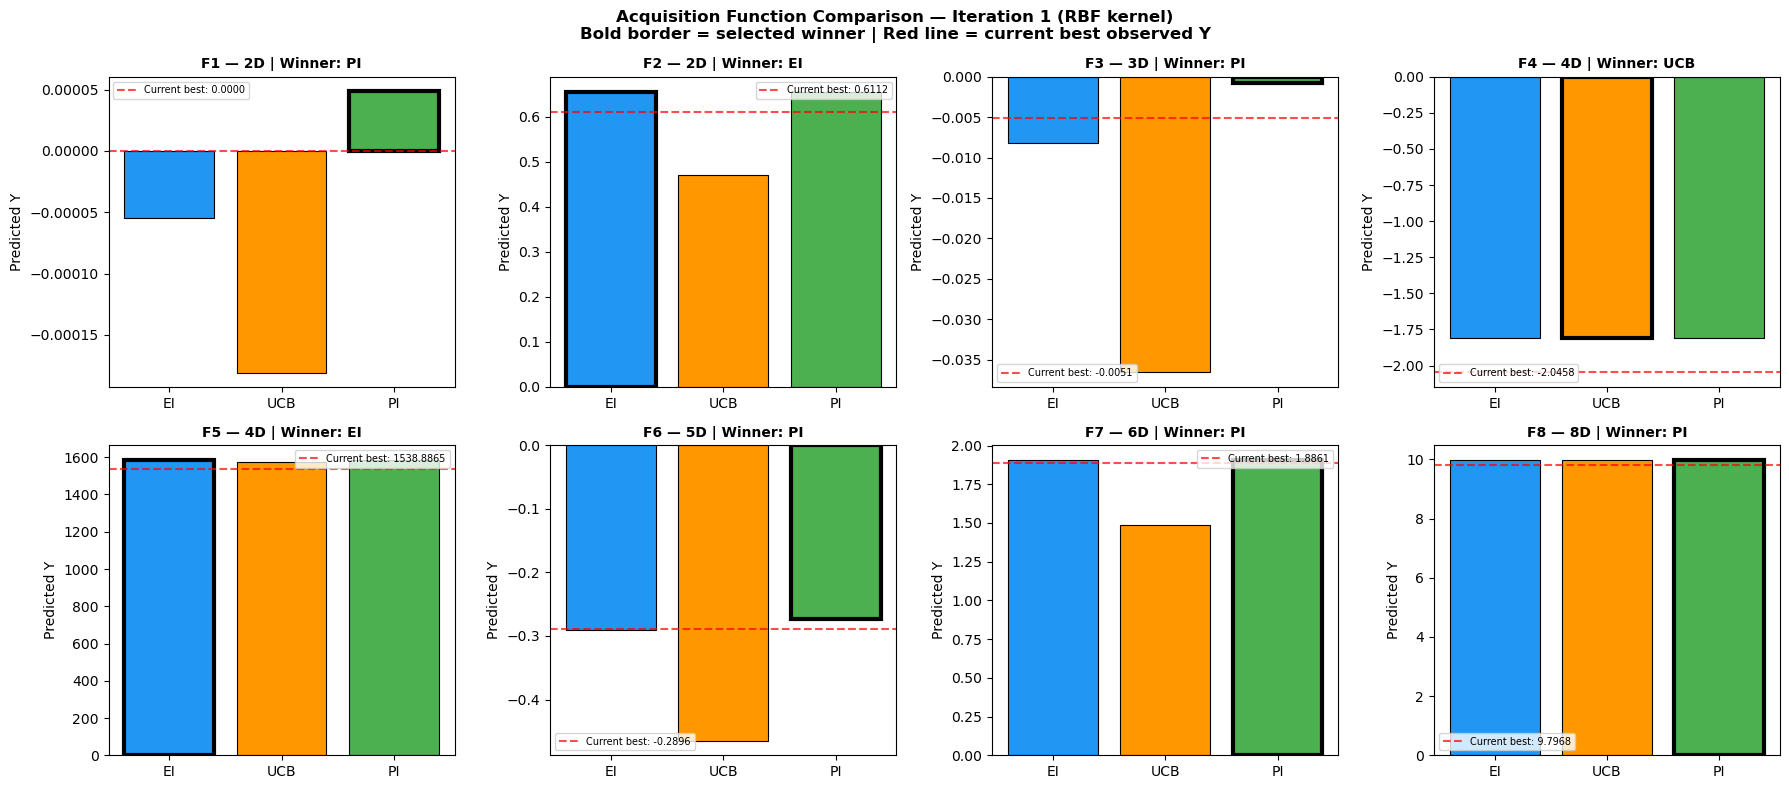

In [78]:
# COMPARING ACQUISITION FUNCTIONS
 
colours = {'EI': '#2196F3', 'UCB': '#FF9800', 'PI': '#4CAF50'}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for fn in range(1, 9):
    ax = axes[fn - 1]
    df_fn = df_all[df_all['function'] == fn]
    winner = df_best.loc[fn, 'acquisition']
    y_current_best = df_best.loc[fn, 'y_max_so_far']

    acq_names   = df_fn['acquisition'].tolist()
    pred_ys     = df_fn['predicted_y'].tolist()
    bar_cols    = [colours[a] for a in acq_names]
    edge_widths = [3 if a == winner else 0.8 for a in acq_names]

    ax.bar(acq_names, pred_ys, color=bar_cols,
           edgecolor='black', linewidth=edge_widths)
    ax.axhline(y_current_best, color='red', linestyle='--',
               alpha=0.7, label=f'Current best: {y_current_best:.4f}')
    ax.set_title(
        f'F{fn} — {all_X[fn-1].shape[1]}D | Winner: {winner}',
        fontsize=10, fontweight='bold'
    )
    ax.set_ylabel('Predicted Y')
    ax.legend(fontsize=7)

fig.suptitle(
    'Acquisition Function Comparison — Iteration 1 (RBF kernel)\n'
    'Bold border = selected winner | Red line = current best observed Y',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

F1: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-79>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


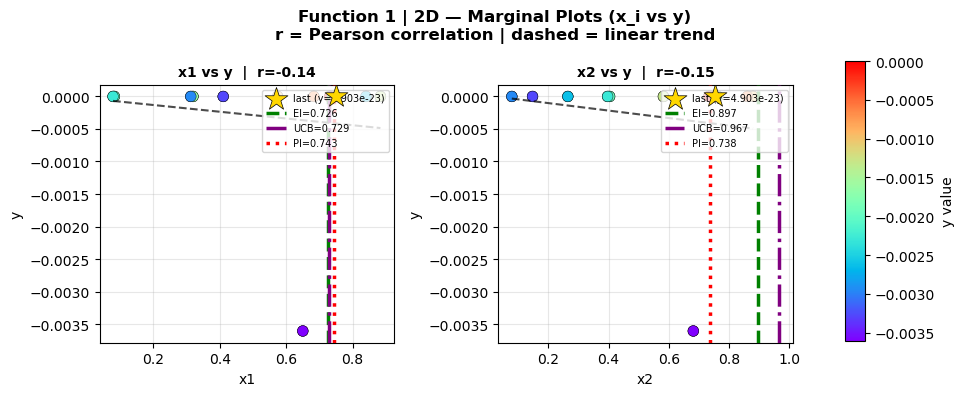

F2: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-79>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


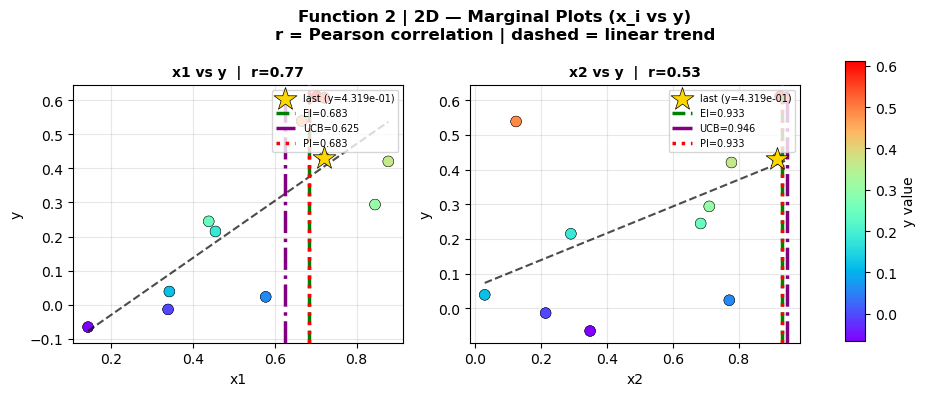

F3: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-79>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


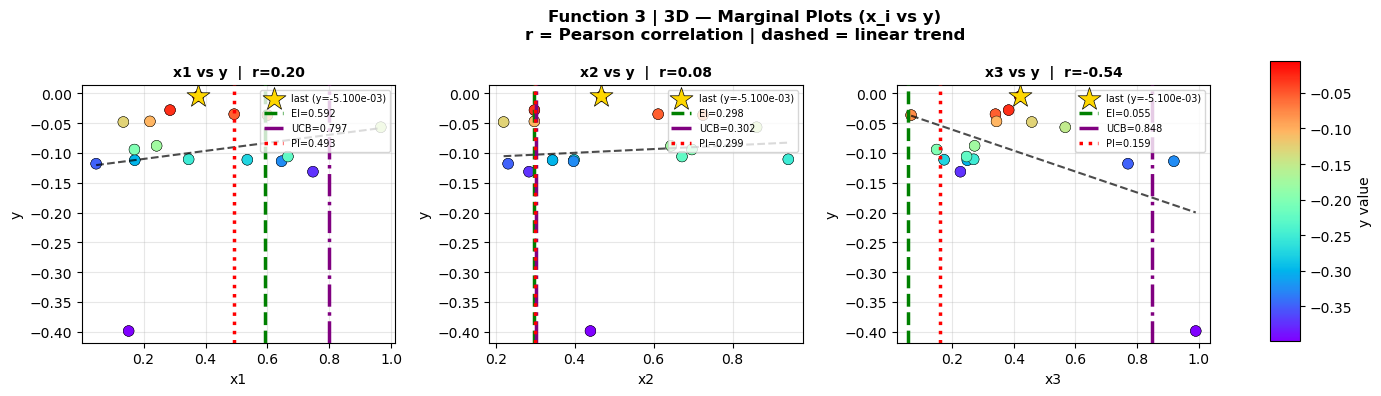

F4: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-79>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


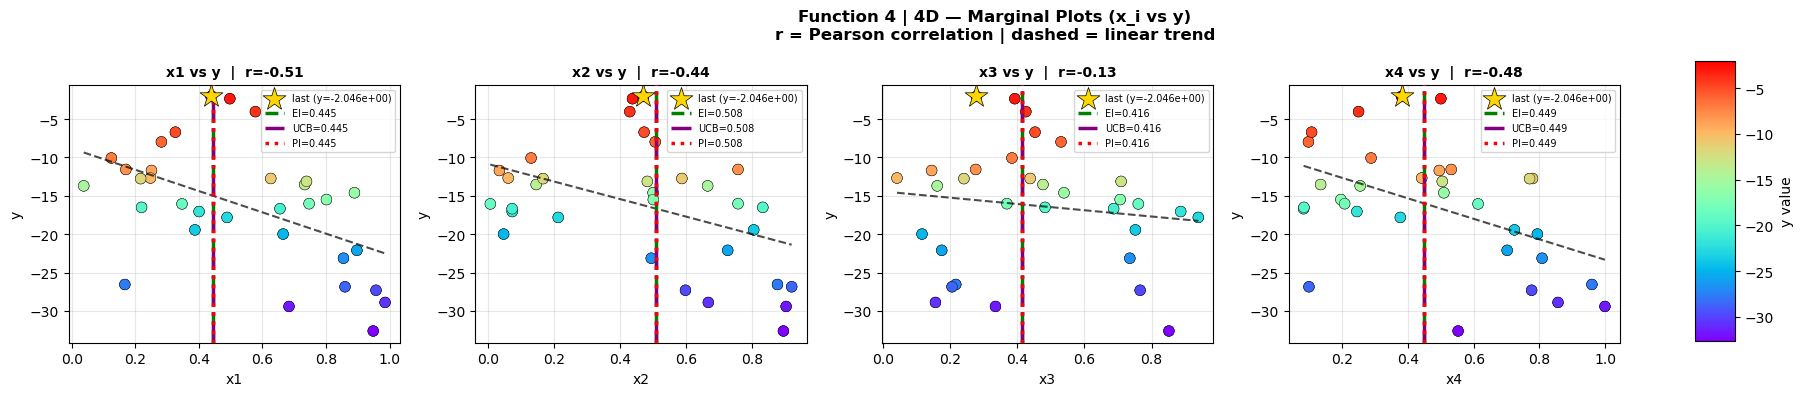

F5: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-79>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


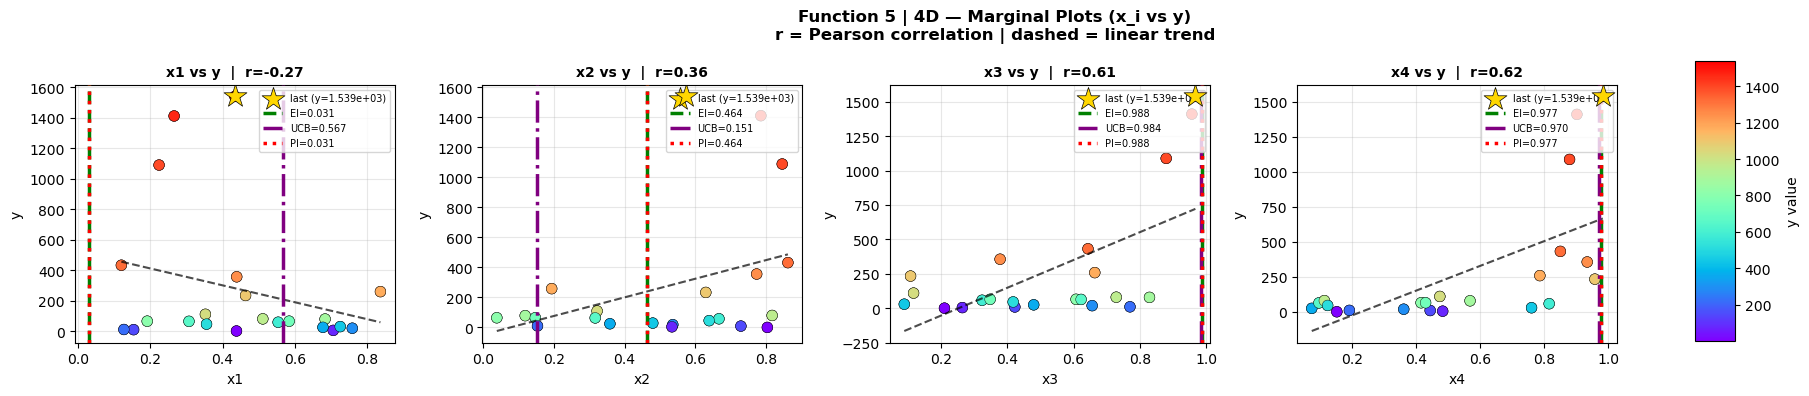

F6: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-79>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


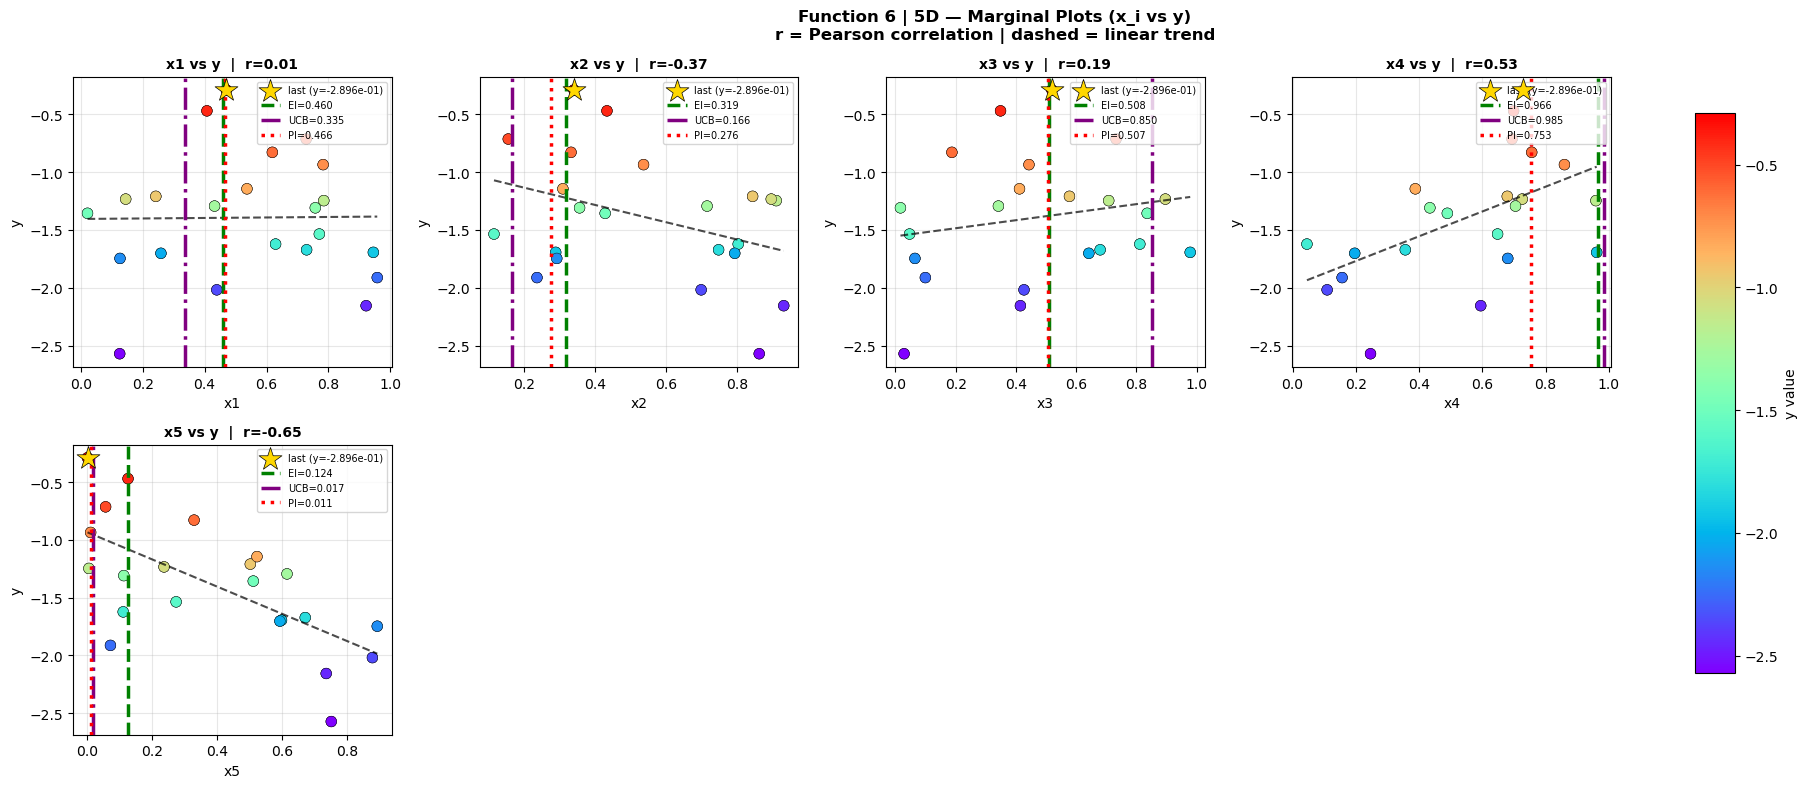

F7: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-79>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


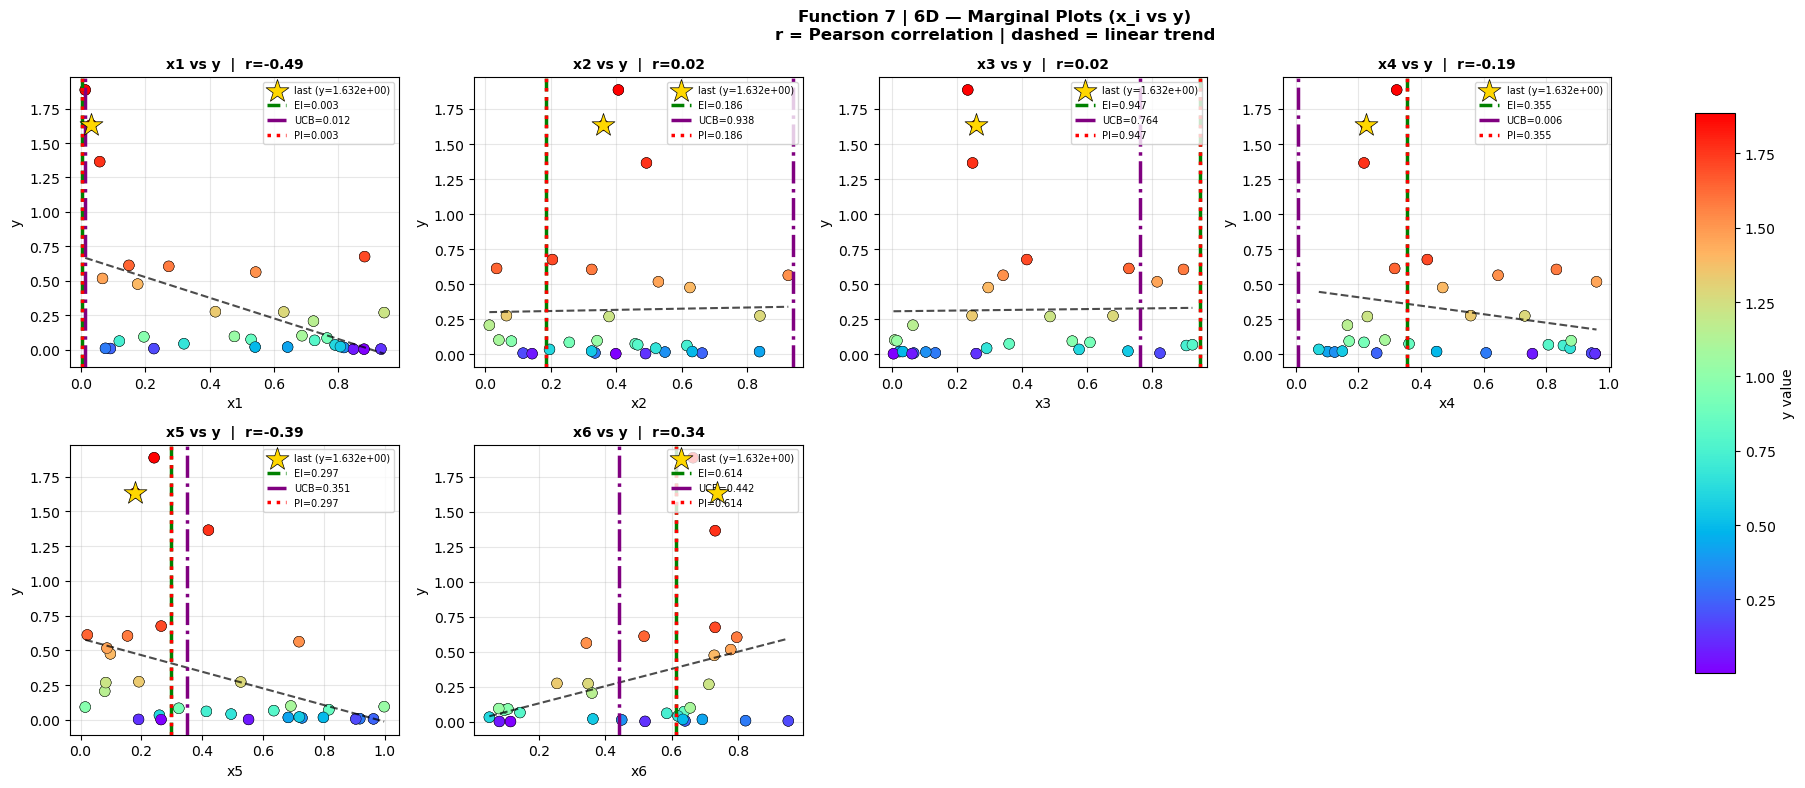

F8: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-79>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


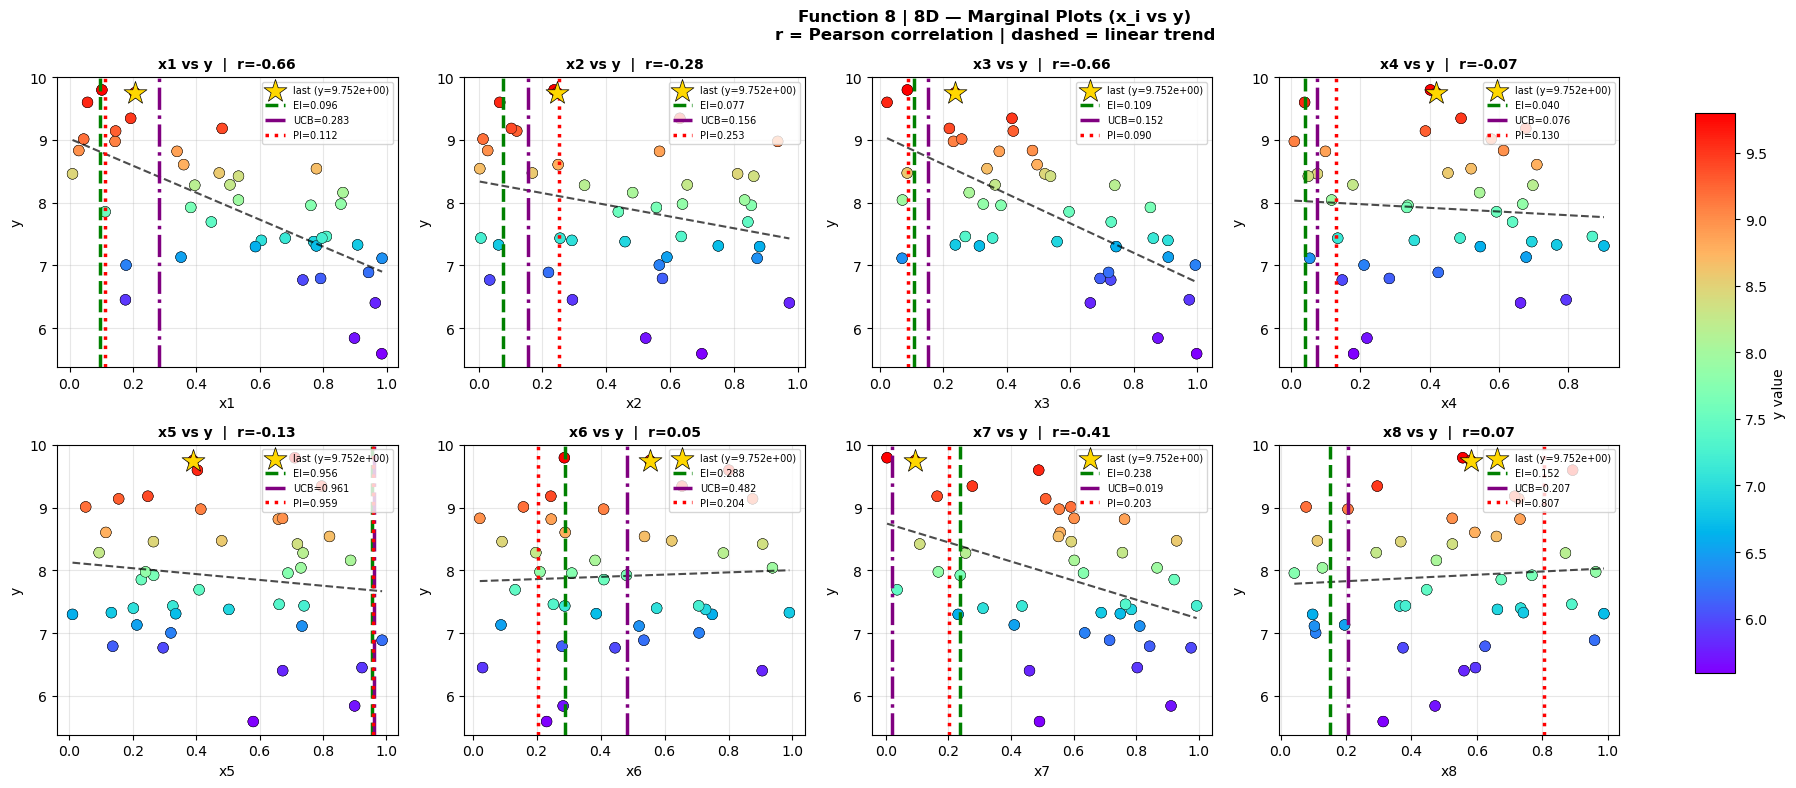

In [79]:
# PLOTTING MARGINAL PLOTS
for fn in range(1, 9):
    plot_function(fn, df_all=df_all)

In [80]:
# RANKING DIMENSIONS

def rank_dimensions(fn_num, top_n=4):
    X = all_X[fn_num - 1]
    y = all_y[fn_num - 1]
    
    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X, y)
    
    importances = rf.feature_importances_
    order = np.argsort(importances)[::-1]
    coverage = importances[order[:top_n]].sum()
    
    print(f"\nF{fn_num} — dimension importance ranking:")
    for rank, i in enumerate(order):
        marker = " ◄ plot" if rank < top_n else ""
        print(f"  {X.columns[i]}: {importances[i]:.4f}{marker}")
    print(f"  Top-{top_n} coverage: {coverage:.1%}")
    
    return X.columns[order[:top_n]].tolist(), rf, order

top_dims = {}

for fn_num in range(1, 9):
    n_dim = all_X[fn_num - 1].shape[1]
    if n_dim <= 4:
        top_dims[fn_num] = all_X[fn_num - 1].columns.tolist()
        print(f"F{fn_num}: {n_dim}D — using all dims: {top_dims[fn_num]}")
    else:
        top_dims[fn_num], _, _ = rank_dimensions(fn_num, top_n=4)  
        
print("\n--- Summary ---")
for fn_num, dims in top_dims.items():
    print(f"F{fn_num}: {dims}")

F1: 2D — using all dims: ['x1', 'x2']
F2: 2D — using all dims: ['x1', 'x2']
F3: 3D — using all dims: ['x1', 'x2', 'x3']
F4: 4D — using all dims: ['x1', 'x2', 'x3', 'x4']
F5: 4D — using all dims: ['x1', 'x2', 'x3', 'x4']

F6 — dimension importance ranking:
  x5: 0.4339 ◄ plot
  x4: 0.3184 ◄ plot
  x2: 0.1114 ◄ plot
  x1: 0.0867 ◄ plot
  x3: 0.0497
  Top-4 coverage: 95.0%

F7 — dimension importance ranking:
  x1: 0.7755 ◄ plot
  x5: 0.0747 ◄ plot
  x6: 0.0599 ◄ plot
  x2: 0.0469 ◄ plot
  x3: 0.0278
  x4: 0.0152
  Top-4 coverage: 95.7%

F8 — dimension importance ranking:
  x3: 0.4025 ◄ plot
  x1: 0.3472 ◄ plot
  x7: 0.1163 ◄ plot
  x5: 0.0381 ◄ plot
  x2: 0.0293
  x6: 0.0241
  x8: 0.0233
  x4: 0.0192
  Top-4 coverage: 90.4%

--- Summary ---
F1: ['x1', 'x2']
F2: ['x1', 'x2']
F3: ['x1', 'x2', 'x3']
F4: ['x1', 'x2', 'x3', 'x4']
F5: ['x1', 'x2', 'x3', 'x4']
F6: ['x5', 'x4', 'x2', 'x1']
F7: ['x1', 'x5', 'x6', 'x2']
F8: ['x3', 'x1', 'x7', 'x5']


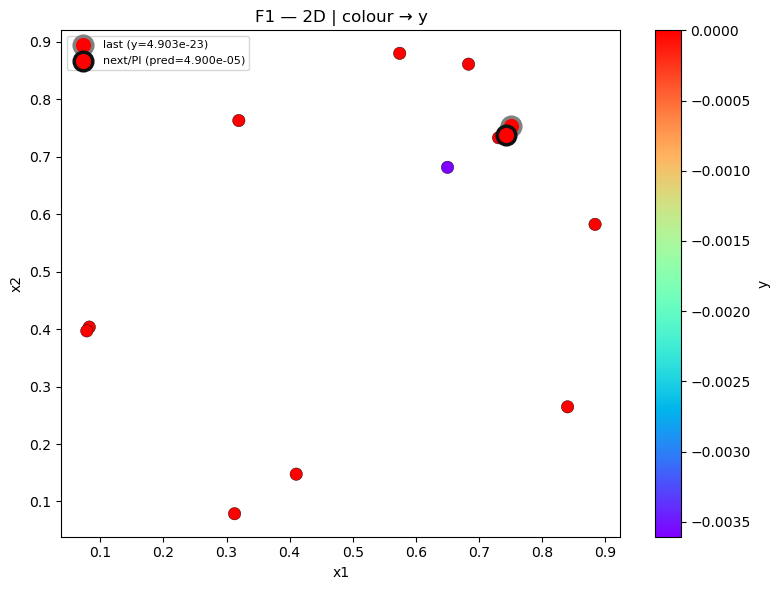

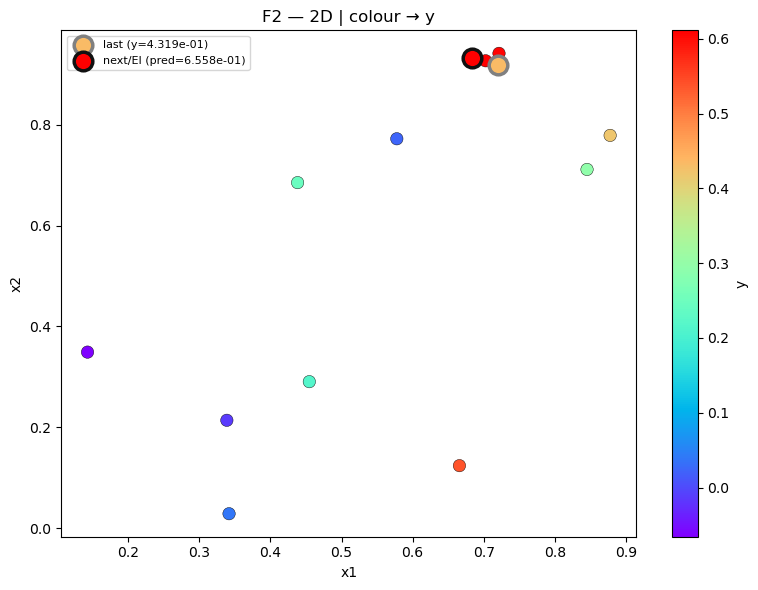

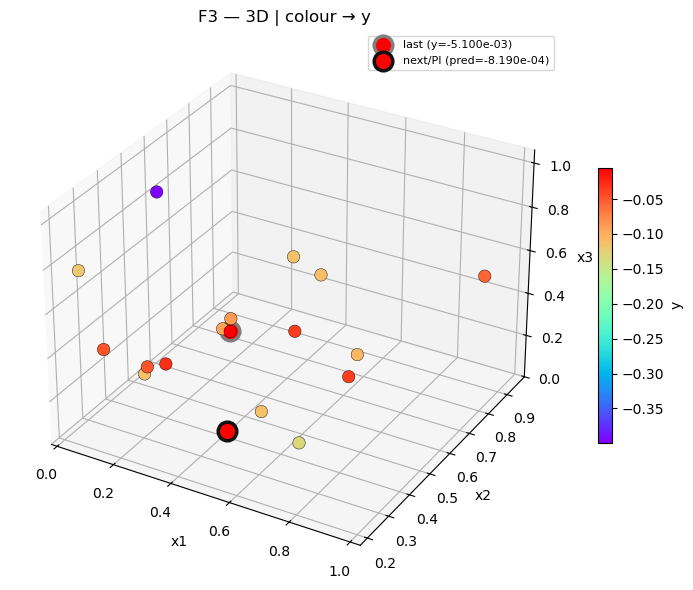

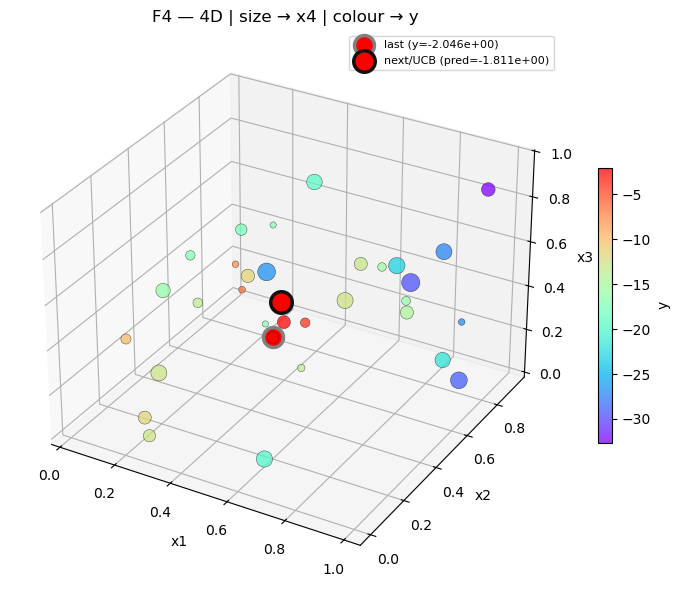

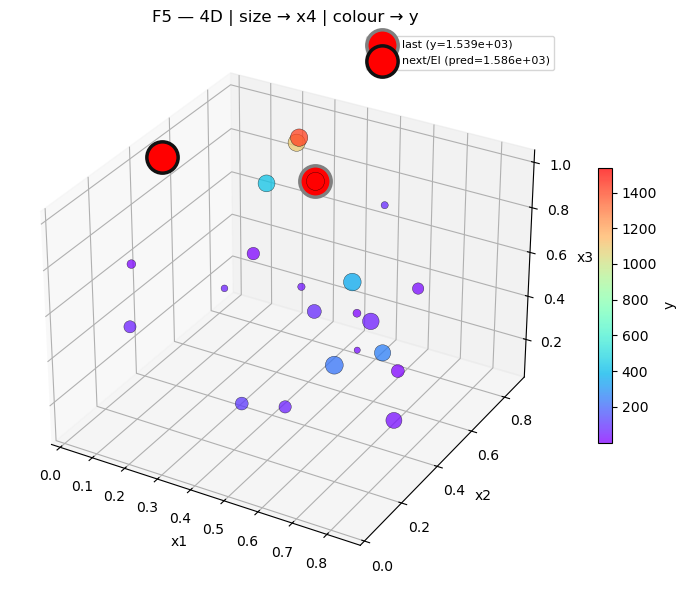

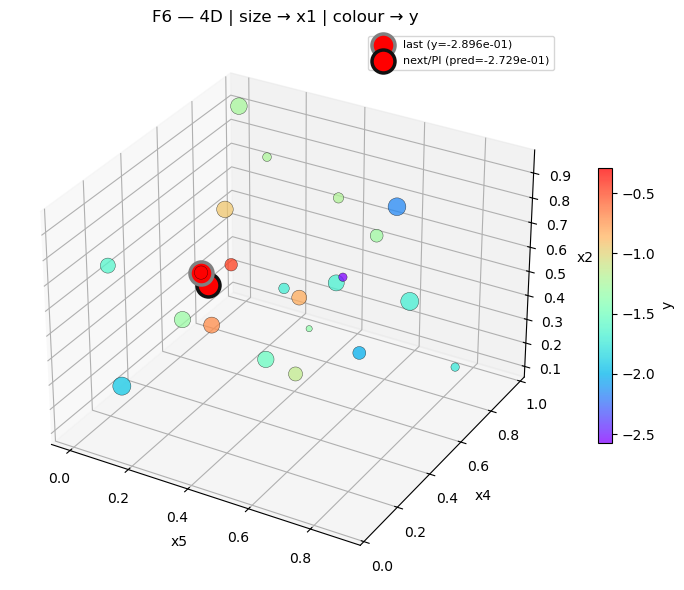

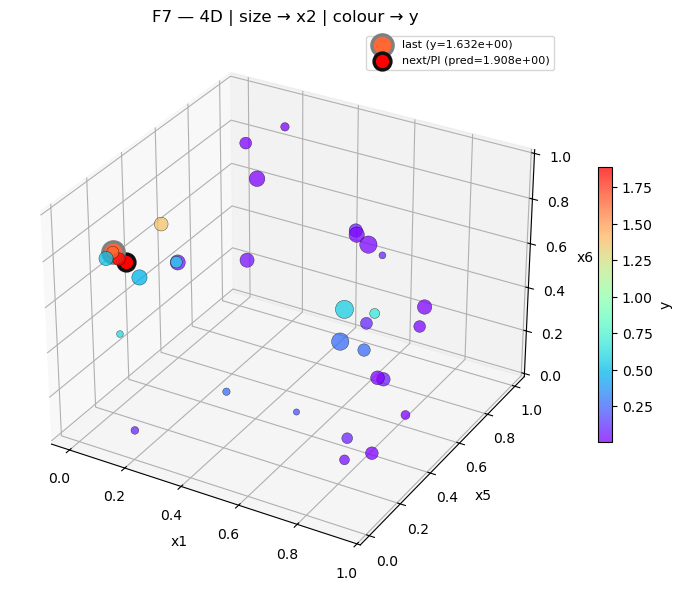

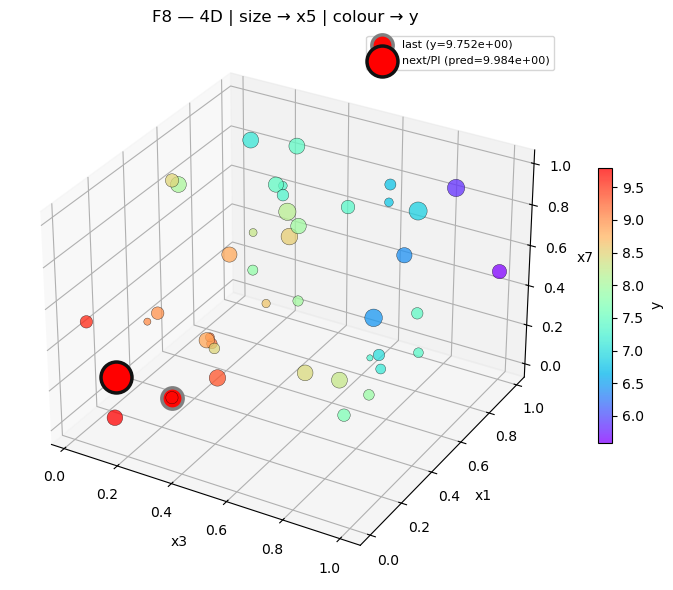

In [81]:


def plot_smart(fn_num, top_dims_dict=top_dims, best_df=df_best):
    X = all_X[fn_num - 1]
    y = all_y[fn_num - 1]
    dims = top_dims_dict[fn_num]
    n_dim = X.shape[1]
    plot_dims = dims if n_dim <= 4 else dims[:4]
    n_plot = len(plot_dims)

    # ── colour setup first so everything can use it
    y_arr = y.values if hasattr(y, 'values') else y
    norm = plt.Normalize(y_arr.min(), y_arr.max())
    cmap = plt.cm.rainbow
    last_color = cmap(norm(y_arr[-1]))

    # ── Pull best suggestion from df_best
    best_row = df_best.loc[fn_num]
    all_dims = all_X[fn_num - 1].columns.tolist()
    coord_map = dict(zip(all_dims, best_row['x_next']))
    sugg_coords = {col: coord_map[col] for col in plot_dims}
    sugg_label = f"next/{best_row['acquisition']} (pred={best_row['predicted_y']:.3e})"
    sugg_color = cmap(norm(best_row['predicted_y']))

    fig = plt.figure(figsize=(8, 6))
    y_arr = y.values if hasattr(y, 'values') else y
    norm = plt.Normalize(y_arr.min(), y_arr.max())
    cmap = plt.cm.rainbow
    last_color = cmap(norm(y_arr[-1]))
    GOLD = '#FFD700'

# ── 2D
    if n_plot == 2:
        d1, d2 = plot_dims
        ax = fig.add_subplot(111)
        sc = ax.scatter(X[d1], X[d2], c=y_arr, cmap=cmap, norm=norm,
                        s=80, alpha=1.0, edgecolors='k', linewidths=0.3)
        # last point — bold grey border
        ax.scatter(X[d1].iloc[-1], X[d2].iloc[-1],
                   marker='o', s=180, color=last_color,
                   edgecolors='grey', linewidths=2.5,
                   zorder=5, label=f'last (y={y_arr[-1]:.3e})')
        # suggested point — bold dark border, colour = predicted_y
        ax.scatter(sugg_coords[d1], sugg_coords[d2],
                   marker='o', s=180, color=sugg_color,
                   edgecolors='#111111', linewidths=2.5,
                   zorder=6, label=sugg_label)
        ax.set_xlabel(d1); ax.set_ylabel(d2)
        ax.legend(fontsize=8)
        fig.colorbar(sc, ax=ax, label='y')
        ax.set_title(f'F{fn_num} — 2D | colour → y')

    # ── 3D no size
    elif n_plot == 3:
        d1, d2, d3 = plot_dims
        ax = fig.add_subplot(111, projection='3d')
        sc = ax.scatter(X[d1], X[d2], X[d3], c=y_arr, cmap=cmap, norm=norm,
                        s=80, alpha=1.0, edgecolors='k', linewidths=0.3)
        # last point — bold grey border
        ax.scatter(X[d1].iloc[-1], X[d2].iloc[-1], X[d3].iloc[-1],
                   marker='o', s=180, color=last_color,
                   edgecolors='grey', linewidths=2.5,
                   zorder=5, label=f'last (y={y_arr[-1]:.3e})')
        # suggested point — bold dark border, colour = predicted_y
        ax.scatter(sugg_coords[d1], sugg_coords[d2], sugg_coords[d3],
                   marker='o', s=180, color=sugg_color,
                   edgecolors='#111111', linewidths=2.5,
                   zorder=6, label=sugg_label)
        ax.set_xlabel(d1); ax.set_ylabel(d2); ax.set_zlabel(d3)
        ax.legend(fontsize=8)
        fig.colorbar(sc, ax=ax, label='y', shrink=0.5)
        ax.set_title(f'F{fn_num} — 3D | colour → y')

    # ── 4D with size
# ── 4D with size
# ── 4D with size
    elif n_plot >= 4:
        d1, d2, d3, d4 = plot_dims[:4]
        x4_vals = X[d4].values
        x4_norm = (x4_vals - x4_vals.min()) / (x4_vals.max() - x4_vals.min() + 1e-12)
        sizes = 20 + x4_norm * 150

        last_x4_norm = (X[d4].iloc[-1] - x4_vals.min()) / (x4_vals.max() - x4_vals.min() + 1e-12)
        last_size = 20 + last_x4_norm * 150

        sugg_x4_norm = (sugg_coords[d4] - x4_vals.min()) / (x4_vals.max() - x4_vals.min() + 1e-12)
        sugg_size = 20 + sugg_x4_norm * 150

        # colour of suggested point based on predicted_y mapped onto same colormap/norm
        sugg_color = cmap(norm(best_row['predicted_y']))

        ax = fig.add_subplot(111, projection='3d')
        sc = ax.scatter(X[d1], X[d2], X[d3], c=y_arr, cmap=cmap, norm=norm,
                        s=sizes, alpha=0.75, edgecolors='k', linewidths=0.3)
        # last point — bold grey border
        ax.scatter(X[d1].iloc[-1], X[d2].iloc[-1], X[d3].iloc[-1],
                marker='o', s=last_size * 3, color=last_color,
                edgecolors='grey', linewidths=2.5,
                zorder=5, label=f'last (y={y_arr[-1]:.3e})')
        # suggested point — bold dark border, colour = predicted_y on same scale
        ax.scatter(sugg_coords[d1], sugg_coords[d2], sugg_coords[d3],
                marker='o', s=sugg_size * 3, color=sugg_color,
                edgecolors='#111111', linewidths=2.5,
                zorder=6, label=sugg_label)
        ax.set_xlabel(d1); ax.set_ylabel(d2); ax.set_zlabel(d3)
        ax.legend(fontsize=8)
        fig.colorbar(sc, ax=ax, label='y', shrink=0.5)
        ax.set_title(f'F{fn_num} — 4D | size → {d4} | colour → y')

    plt.tight_layout()
    plt.show()

for fn_num in range(1, 9):
    plot_smart(fn_num)

F1 skipped — near-flat function


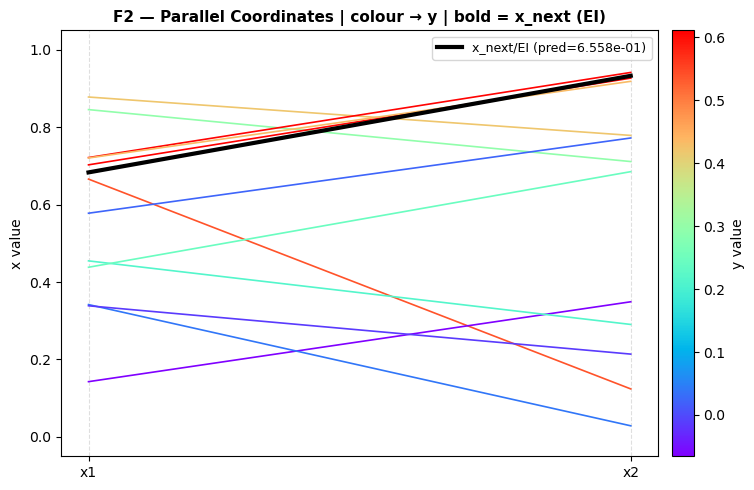

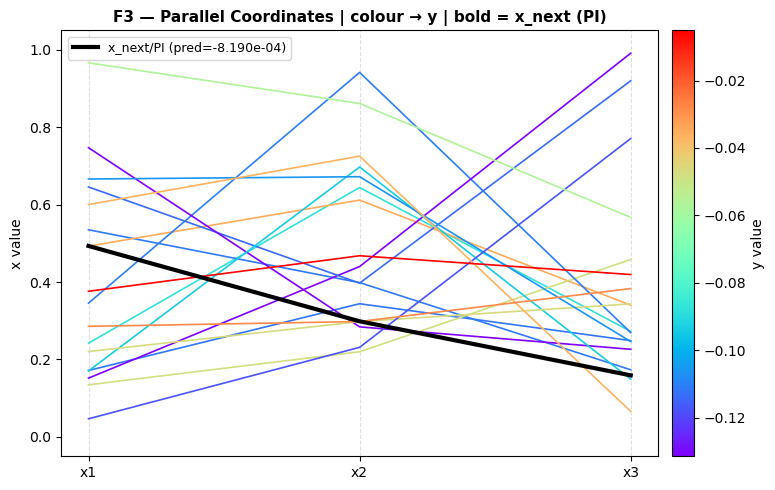

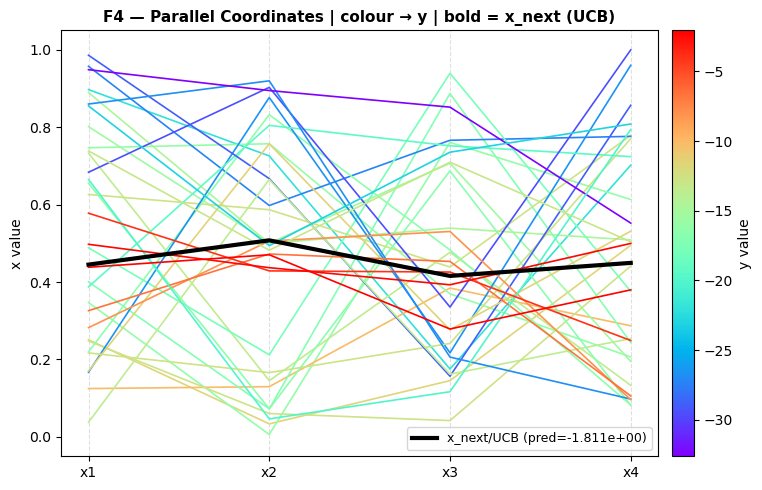

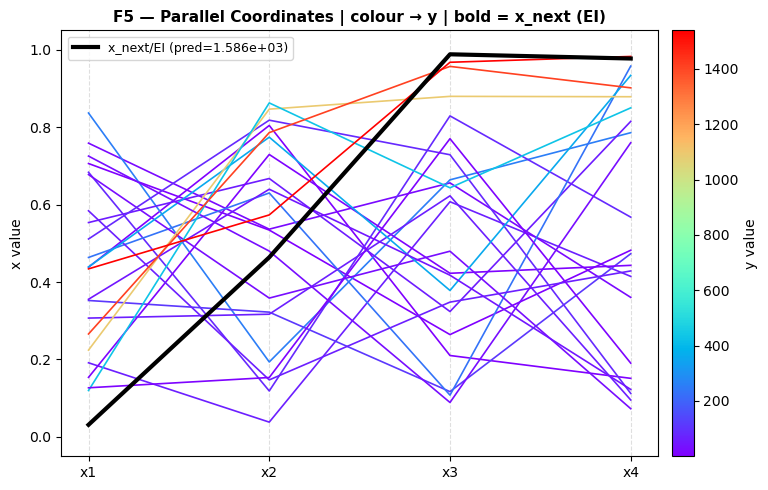

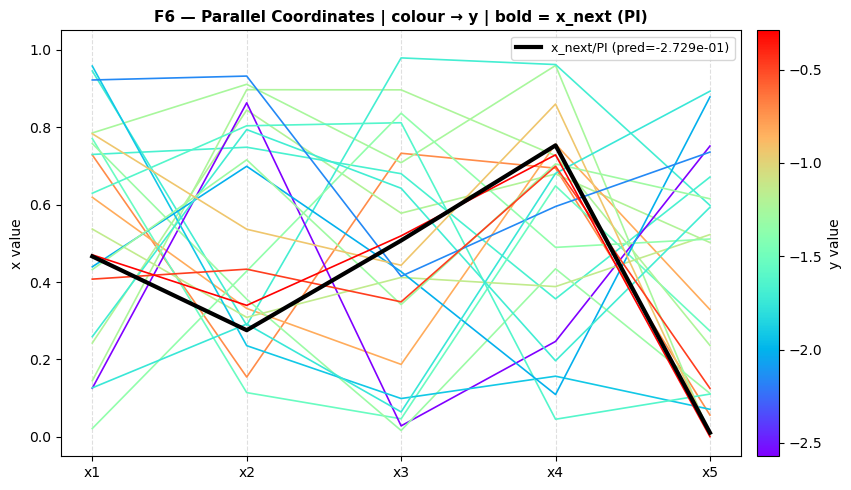

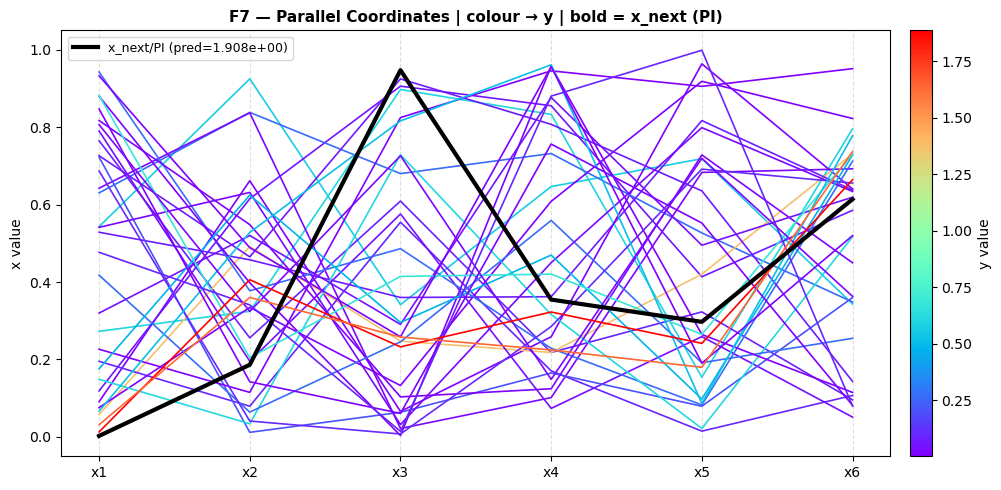

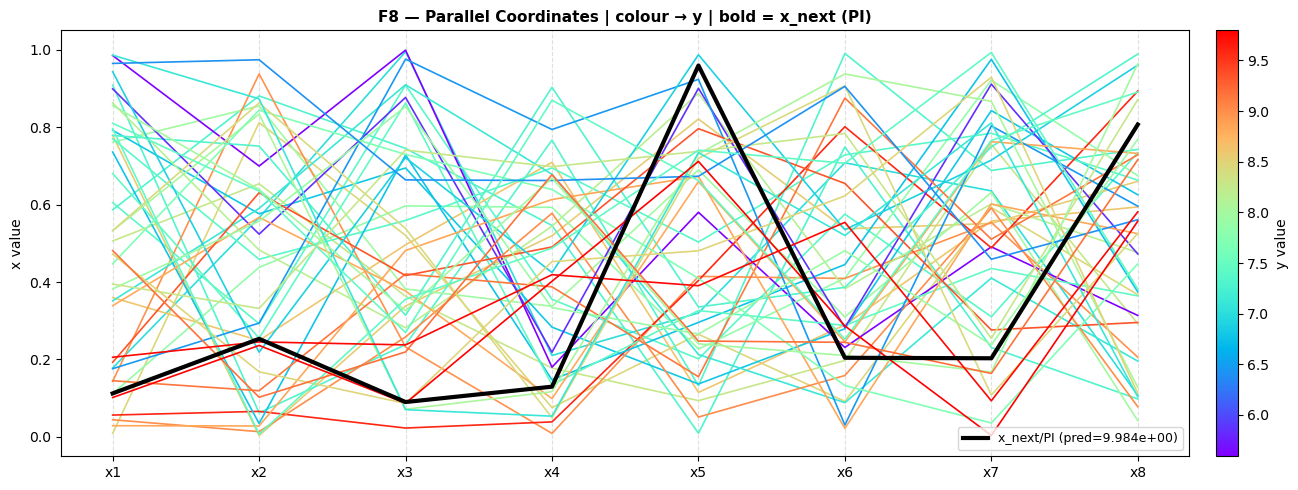

In [82]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

def plot_parallel_coords(fn_num, df_best=df_best, clip_bottom=False):
    X     = all_X[fn_num - 1]
    y     = all_y[fn_num - 1]
    y_arr = y.values if hasattr(y, 'values') else y
    dims  = X.columns.tolist()
    n_dim = len(dims)

    if clip_bottom and len(y_arr) > 1:
        drop_idx   = np.argmin(y_arr)
        y_for_norm = np.delete(y_arr, drop_idx)
    else:
        y_for_norm = y_arr

    norm = mcolors.Normalize(vmin=y_for_norm.min(), vmax=y_for_norm.max())
    cmap = cm.rainbow

    best_row  = df_best.loc[fn_num]
    x_next    = np.array([float(v) for v in best_row['submission'].split('-')])
    acq_label = best_row['acquisition']
    pred_y    = best_row['predicted_y']

    fig, ax = plt.subplots(figsize=(max(8, n_dim * 1.8), 5))
    x_positions = np.arange(n_dim)

    for i in range(len(X)):
        vals  = X.iloc[i].values
        color = cmap(norm(np.clip(y_arr[i], y_for_norm.min(), y_for_norm.max())))
        ax.plot(x_positions, vals, color=color, linewidth=1.2, alpha=1.0)

    ax.plot(x_positions, x_next, color='black', linewidth=3.0,
            zorder=5, label=f'x_next/{acq_label} (pred={pred_y:.3e})')

    ax.set_xticks(x_positions)
    ax.set_xticklabels(dims, fontsize=10)
    ax.set_ylabel('x value', fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.legend(fontsize=9)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='y value', pad=0.02)

    ax.set_title(f'F{fn_num} — Parallel Coordinates | colour → y | bold = x_next ({acq_label})',
                 fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()

for fn_num in range(1, 9):
    if fn_num == 1:
        print('F1 skipped — near-flat function')
        continue
    plot_parallel_coords(fn_num, clip_bottom=(fn_num == 3))

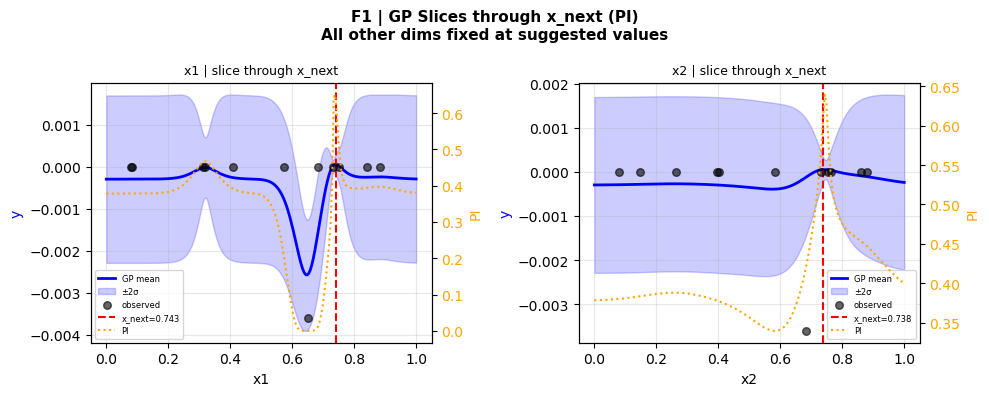

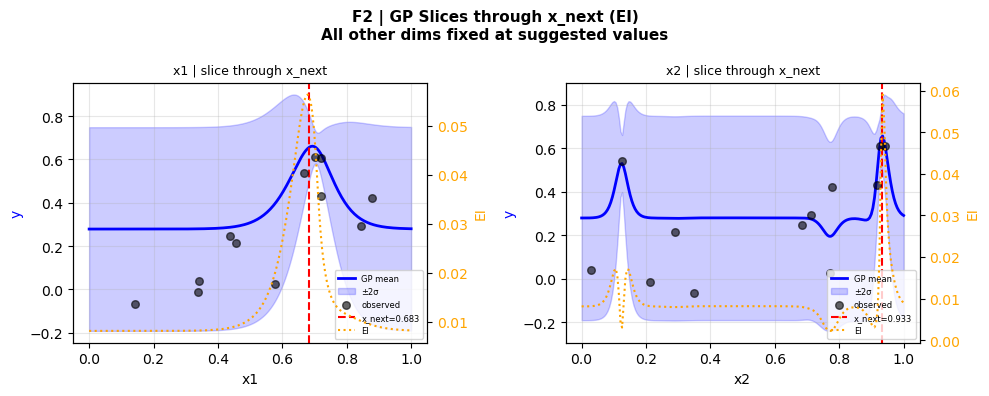

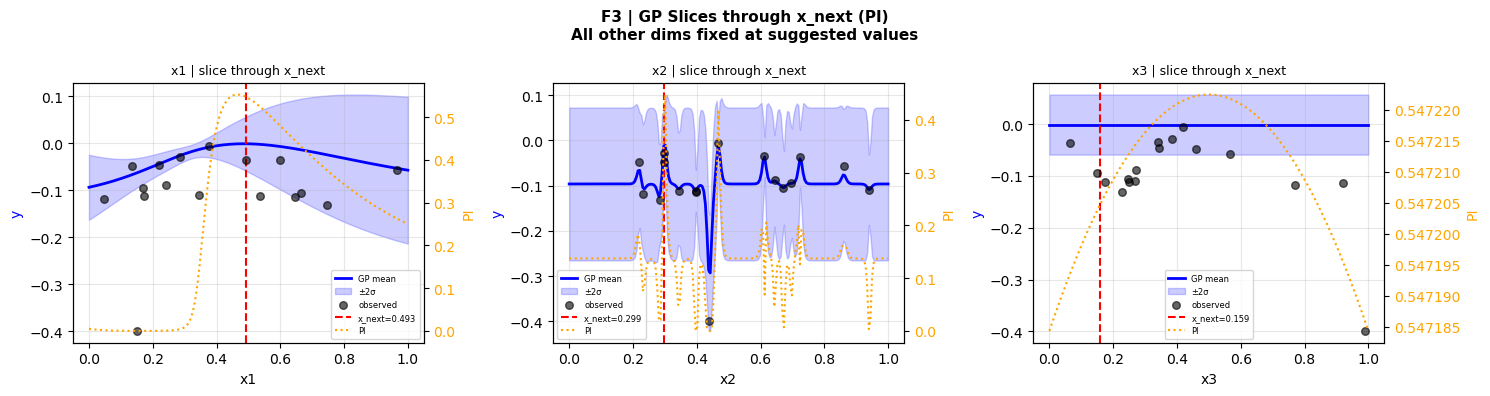

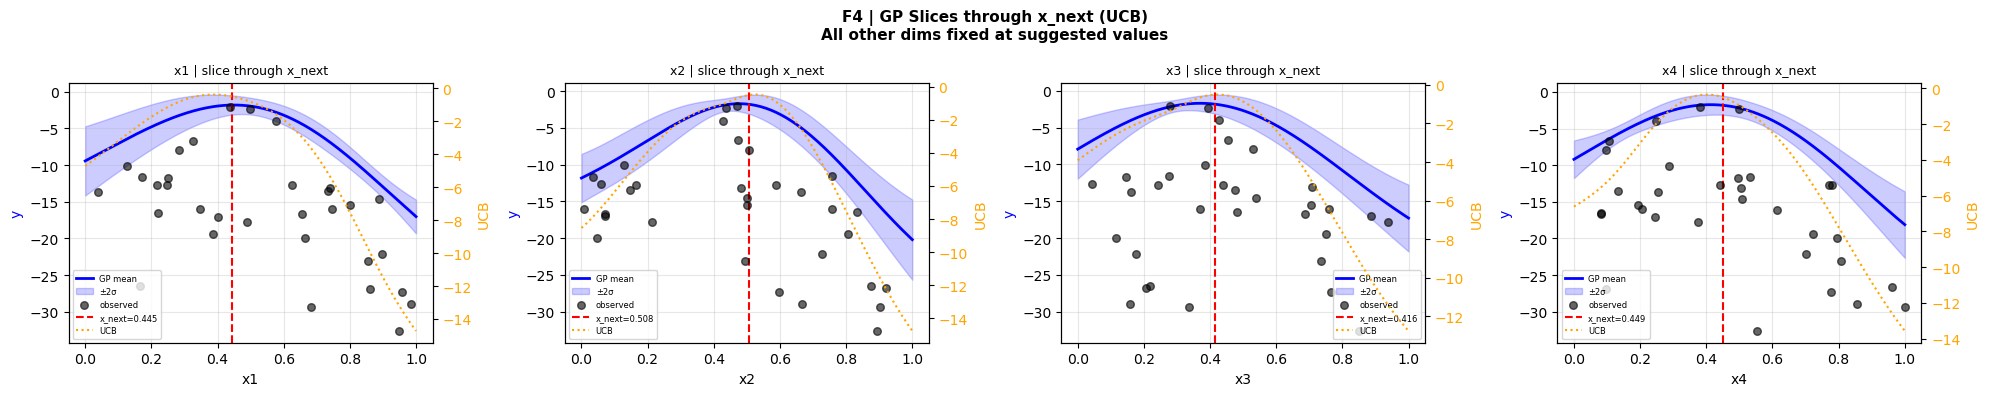

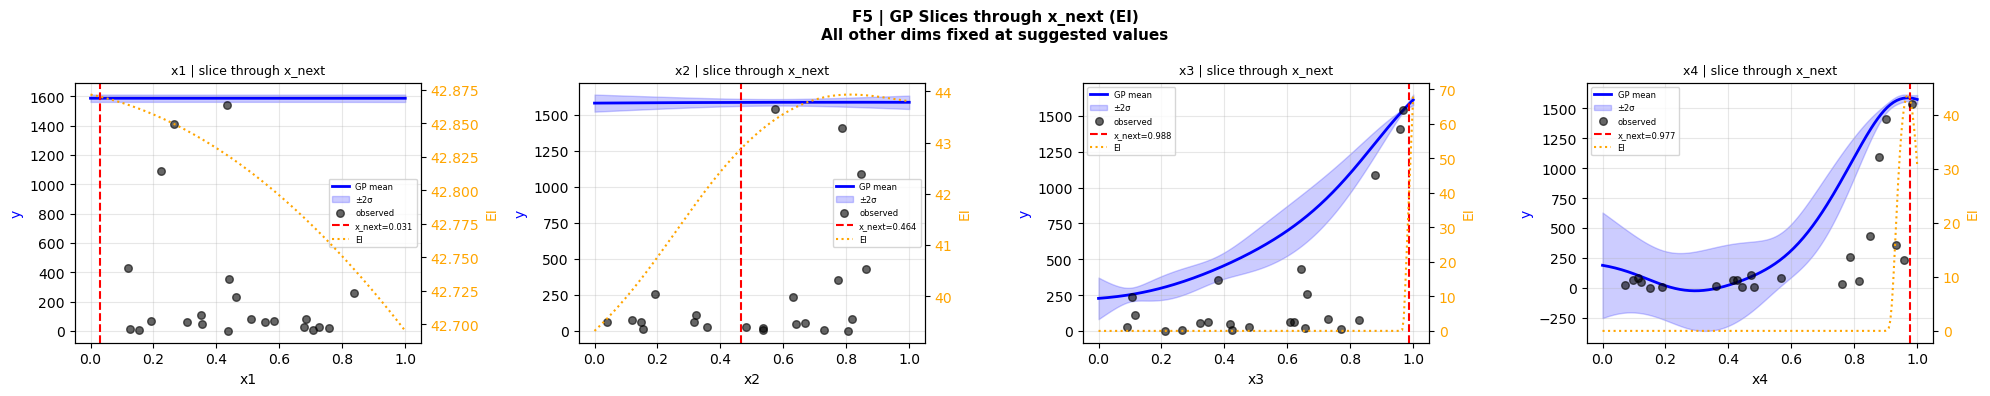

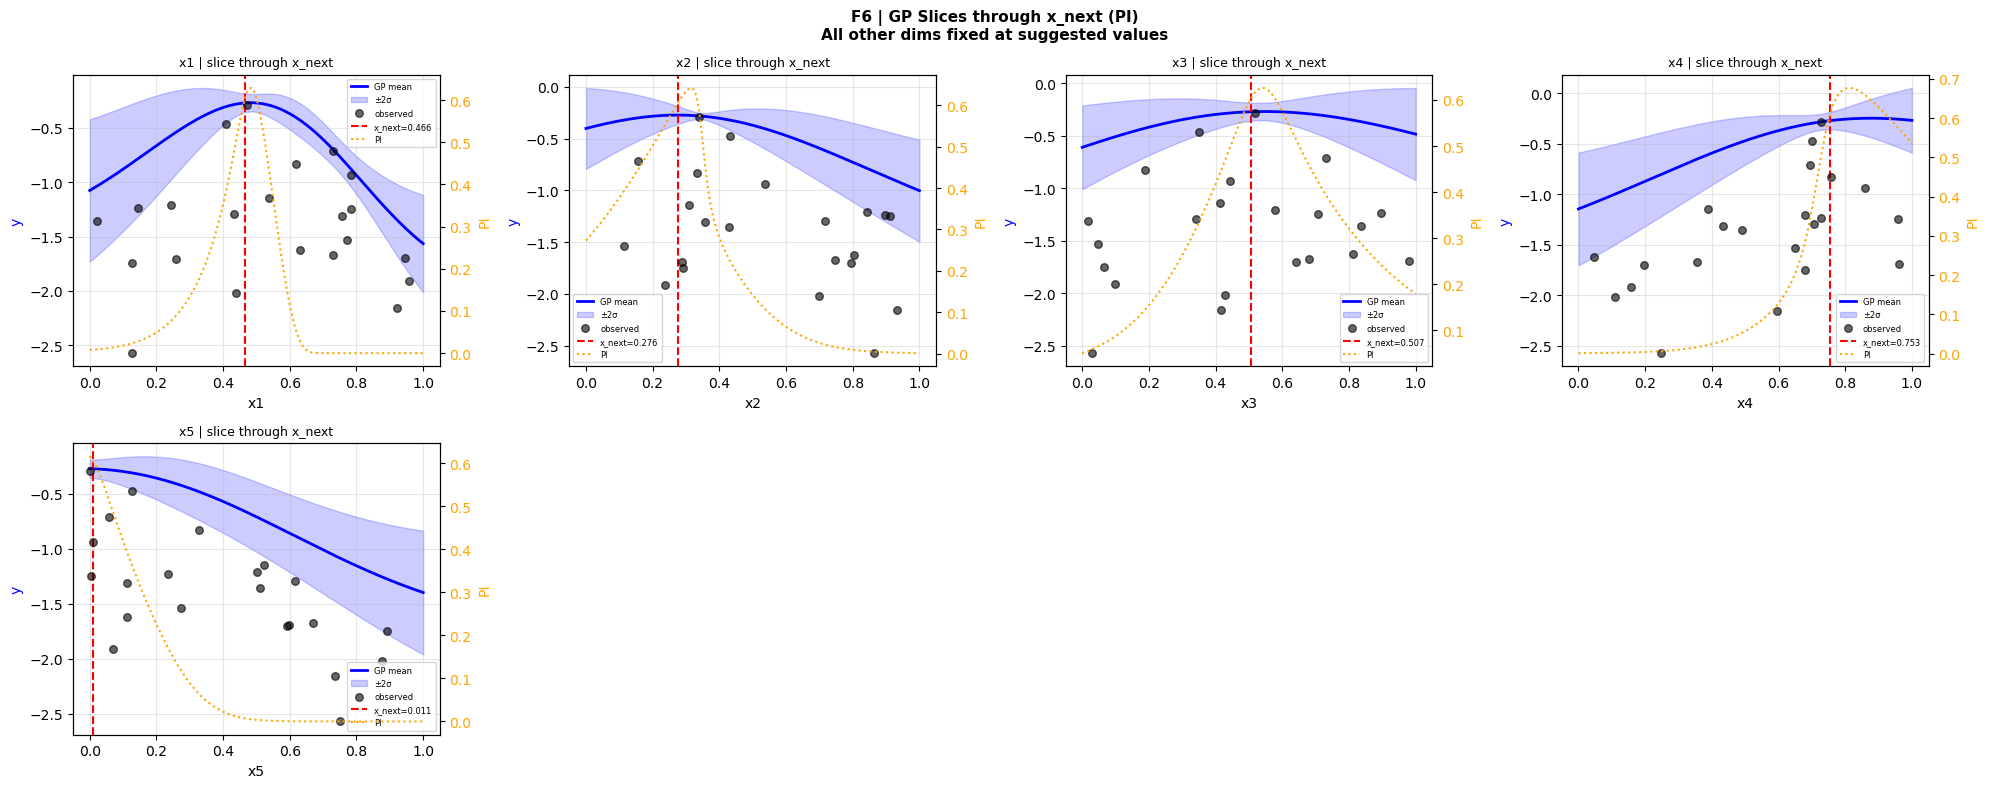

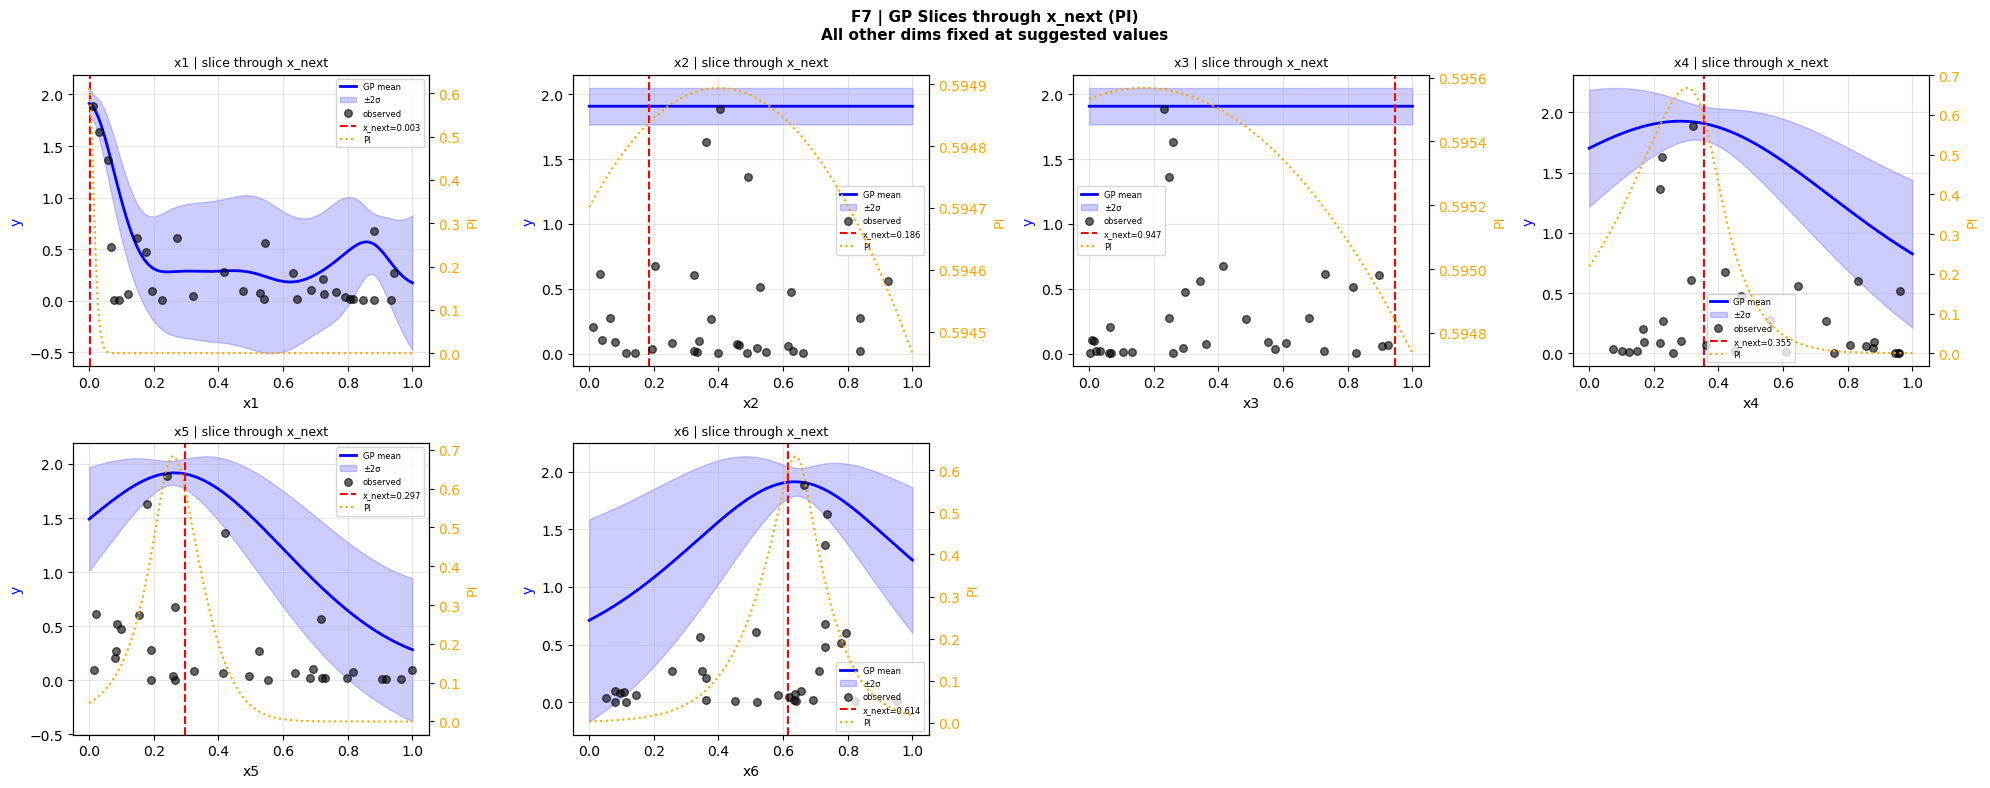

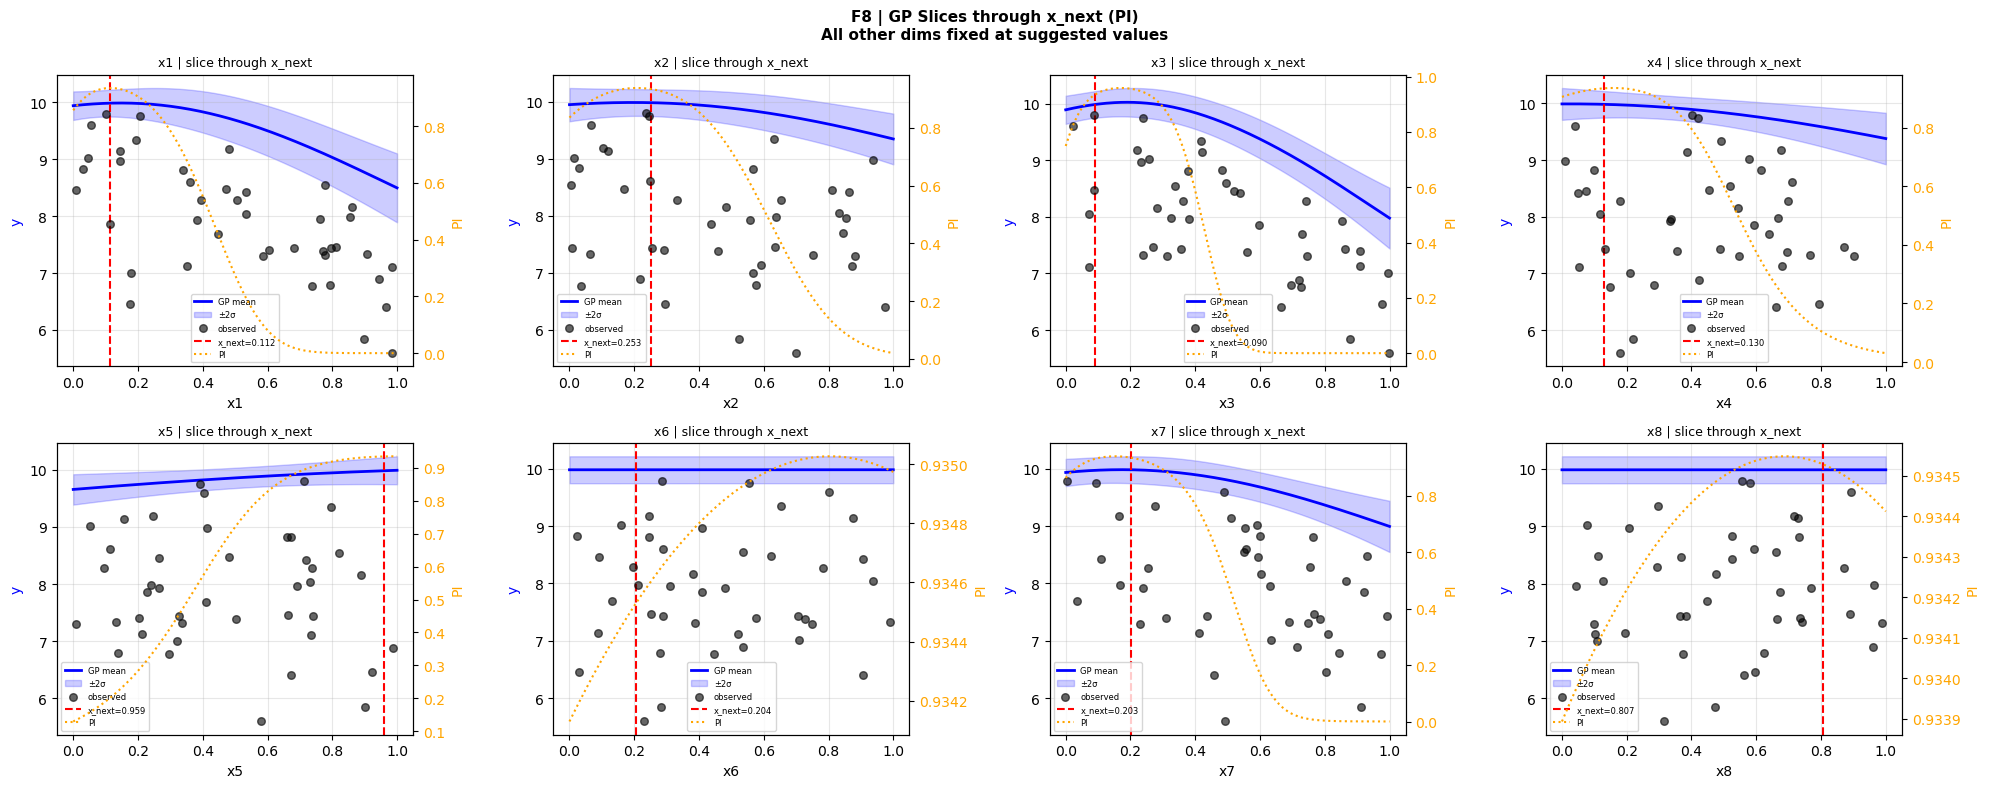

In [83]:
# SLICING GP

def plot_gp_slices(fn_num, gp, df_best, n_points=200):
    X        = all_X[fn_num - 1]
    y        = all_y[fn_num - 1]
    n_dim    = X.shape[1]
    dim_cols = X.columns.tolist()


    sub   = df_best.loc[fn_num, 'submission']
    x_ref = np.array([float(v) for v in sub.split('-')])
    acq   = df_best.loc[fn_num, 'acquisition']
    y_max = float(df_best.loc[fn_num, 'y_max_so_far'])

    n_cols = min(4, n_dim)
    n_rows = int(np.ceil(n_dim / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5*n_cols, 4*n_rows),
                             squeeze=False)

    t = np.linspace(1e-6, 0.999999, n_points)

    for idx, col in enumerate(dim_cols):
        row, col_idx = divmod(idx, n_cols)
        ax1 = axes[row][col_idx]

        X_slice = np.tile(x_ref, (n_points, 1))
        X_slice[:, idx] = t

        mu, sigma = gp.predict(X_slice, return_std=True)

  
        ax1.plot(t, mu, 'b-', linewidth=2, label='GP mean')
        ax1.fill_between(t, mu - 2*sigma, mu + 2*sigma,
                         alpha=0.2, color='blue', label='±2σ')
        ax1.scatter(X[col], y, color='black', s=30, zorder=5,
                    alpha=0.6, label='observed')
        ax1.axvline(x_ref[idx], color='red', linestyle='--',
                    linewidth=1.5, label=f'x_next={x_ref[idx]:.3f}')
        ax1.set_xlabel(col)
        ax1.set_ylabel('y', color='blue')
        ax1.set_title(f'{col} | slice through x_next', fontsize=9)
        ax1.grid(True, alpha=0.3)

        # ── Acquisition on twin axis
        ax2 = ax1.twinx()
        if acq == 'EI':
            a_vals = acq_EI(mu, sigma, y_max, all_y[fn_num - 1].values)
        elif acq == 'UCB':
            t_current = len(all_y[fn_num - 1])   
            d_current = all_X[fn_num - 1].shape[1]
            a_vals = acq_UCB(mu, sigma, y_max, all_y[fn_num - 1].values, t=t_current, d=d_current)

        else:
            a_vals = acq_PI(mu, sigma, y_max, all_y[fn_num - 1].values)

        ax2.plot(t, a_vals, color='orange', linewidth=1.5,
                 linestyle=':', label=f'{acq}')
        ax2.set_ylabel(acq, color='orange')
        ax2.tick_params(axis='y', labelcolor='orange')

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1+lines2, labels1+labels2, fontsize=6)

    for idx in range(n_dim, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r][c].set_visible(False)

    plt.suptitle(f'F{fn_num} | GP Slices through x_next ({acq})\n'
                 f'All other dims fixed at suggested values',
                 fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()

# Usage
for fn in range(1, 9):
    plot_gp_slices(fn, gps[fn], df_best)

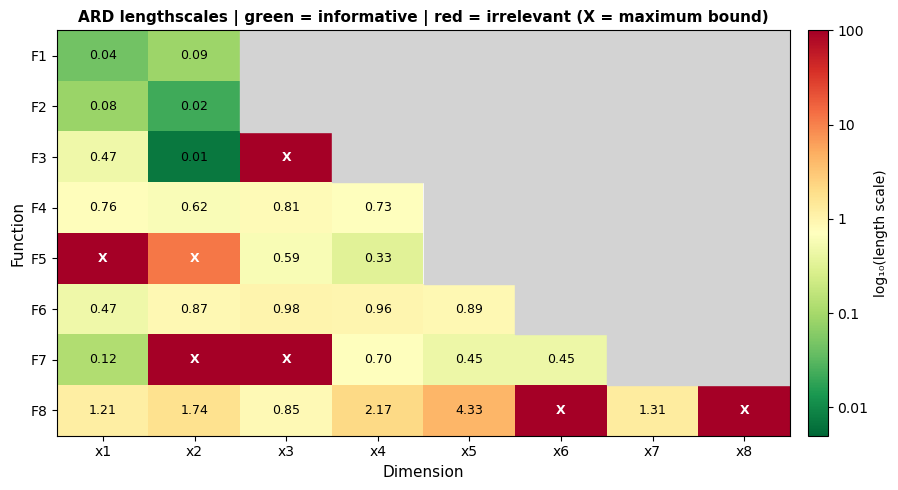

In [84]:


length_scale_df = []

for fn_num in range(1, 9):
    gp = gps[fn_num]
    ls = gp.kernel_.length_scale
    dim_cols = all_X[fn_num - 1].columns.tolist()
    
    row = {'function': fn_num, 'dimensions': len(dim_cols)}
    for col, l in zip(dim_cols, ls):
        row[col] = round(float(l), 4)
    length_scale_df.append(row)

df_ls = pd.DataFrame(length_scale_df).set_index('function')


def plot_lengthscale_heatmap(df_ls, threshold=10.0):
    # Extract only x columns
    x_cols = [c for c in df_ls.columns if c.startswith('x')]
    data = df_ls[x_cols].values.astype(float)
    
    # Log scale
    log_data = np.log10(np.where(np.isnan(data), np.nan, data))
    
    fig, ax = plt.subplots(figsize=(max(8, len(x_cols)*1.2), 5))
    
    # Mask NaN (dimensions that don't exist for that function)
    masked = np.ma.masked_invalid(log_data)
    
    im = ax.imshow(masked, cmap='RdYlGn_r', aspect='auto',
                   vmin=np.log10(0.005), vmax=np.log10(100))
    
    # Annotate cells
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if not np.isnan(data[i, j]):
                val = data[i, j]
                label = f'{val:.2f}' if val < 10 else f'{val:.0f}'
                # Mark irrelevant dims with X
                marker = 'X' if val >= threshold else label
                color = 'white' if val >= threshold else 'black'
                ax.text(j, i, marker, ha='center', va='center',
                       fontsize=9, color=color, fontweight='bold' if val >= threshold else 'normal')
    
    ax.set_xticks(range(len(x_cols)))
    ax.set_xticklabels(x_cols, fontsize=10)
    ax.set_yticks(range(len(df_ls)))
    ax.set_yticklabels([f'F{fn}' for fn in df_ls.index], fontsize=10)
    ax.set_xlabel('Dimension', fontsize=11)
    ax.set_ylabel('Function', fontsize=11)
    ax.set_title('ARD lengthscales | green = informative | red = irrelevant (X = maximum bound)',
                fontweight='bold', fontsize=11)
    
    # Colorbar with original scale ticks
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label('log₁₀(length scale)', fontsize=10)
    cbar.set_ticks([np.log10(v) for v in [0.01, 0.1, 1, 10, 100]])
    cbar.set_ticklabels(['0.01', '0.1', '1', '10', '100'])
    
    # Grey out non-existent dimensions
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if np.isnan(data[i, j]):
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             fill=True, color='lightgrey', zorder=0))
    
    plt.tight_layout()
    plt.show()

plot_lengthscale_heatmap(df_ls)

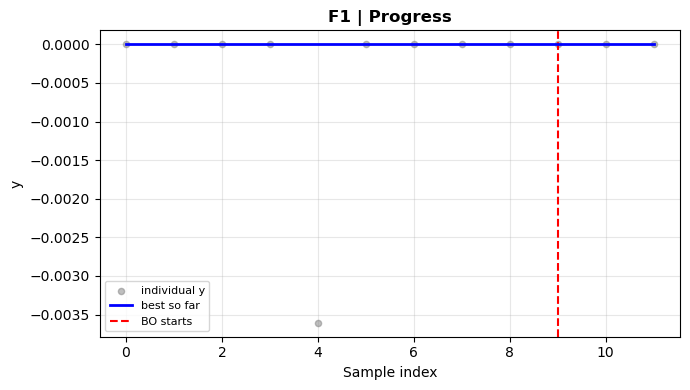

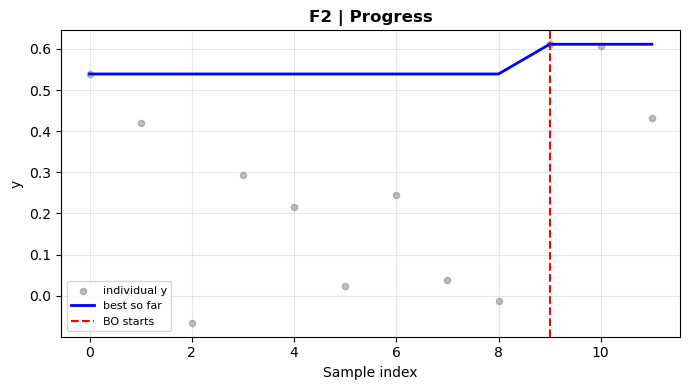

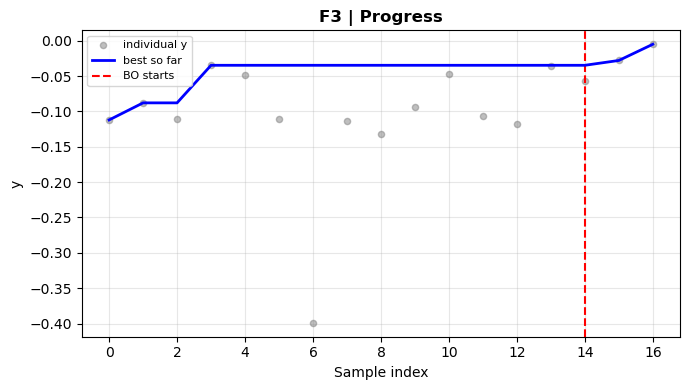

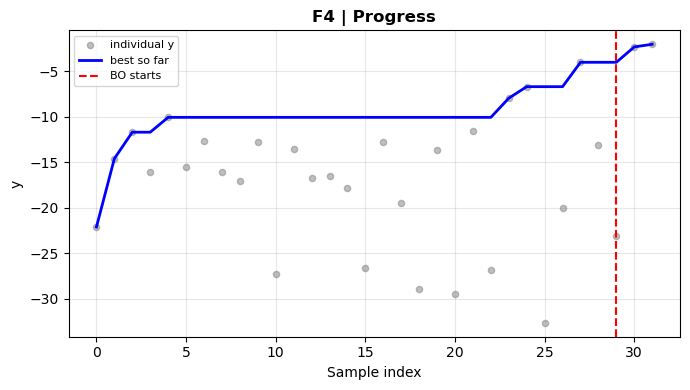

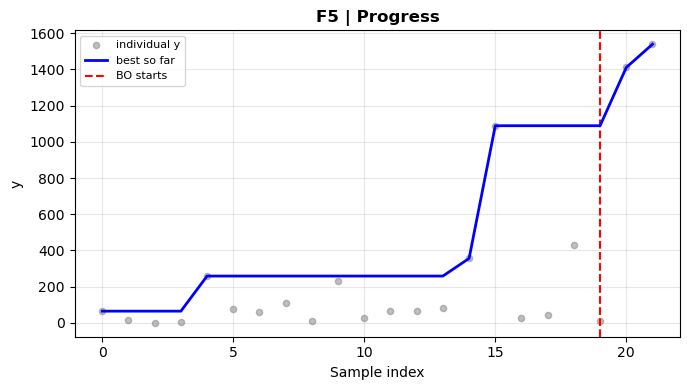

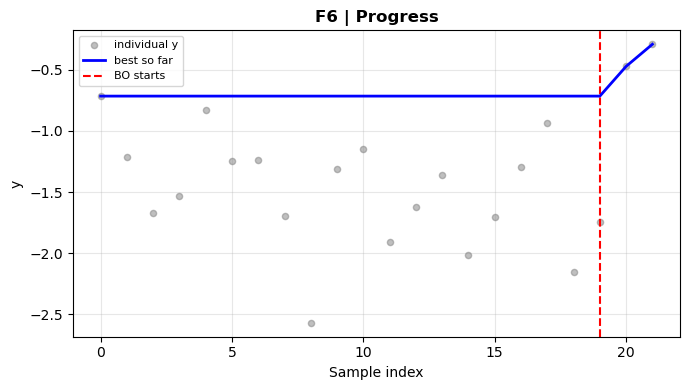

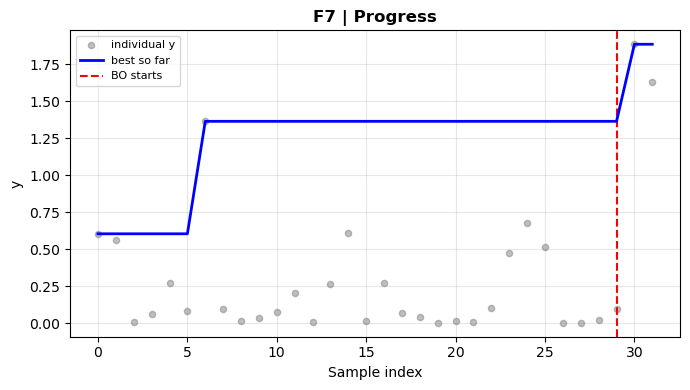

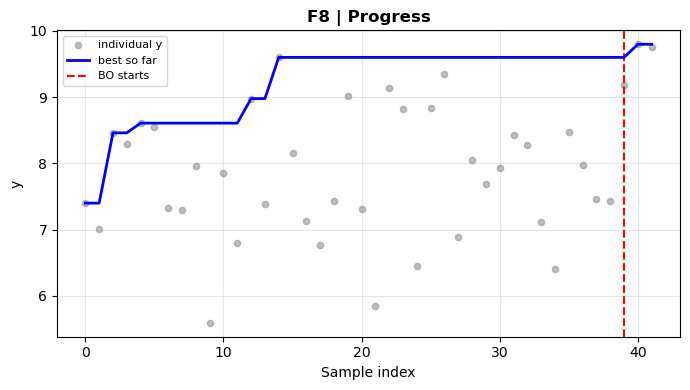

In [85]:
# TRACKING PROGRESS

def plot_progress(fn_num):
    y = all_y[fn_num - 1].values
    n_initial = [10, 10, 15, 30, 20, 20, 30, 40][fn_num - 1]
    
    running_max = np.maximum.accumulate(y)
    iterations = np.arange(len(y))
    
    fig, ax = plt.subplots(figsize=(7, 4))
    
    ax.scatter(iterations, y, color='grey', s=20, alpha=0.5, 
               zorder=2, label='individual y')
    
    ax.plot(iterations, running_max, color='blue', 
            linewidth=2, zorder=3, label='best so far')
    
    ax.axvline(n_initial - 1, color='red', linestyle='--', 
               linewidth=1.5, label='BO starts')
    
    ax.set_xlabel('Sample index')
    ax.set_ylabel('y')
    ax.set_title(f'F{fn_num} | Progress', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

for fn in range(1, 9):
    plot_progress(fn)

F1 | RBF (no ARD): RBF(length_scale=0.047)
F1 | RBF (ARD): RBF(length_scale=[0.0196, 100])
F1 | Matérn 5/2 (ARD): Matern(length_scale=[0.0439, 0.0859], nu=2.5)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


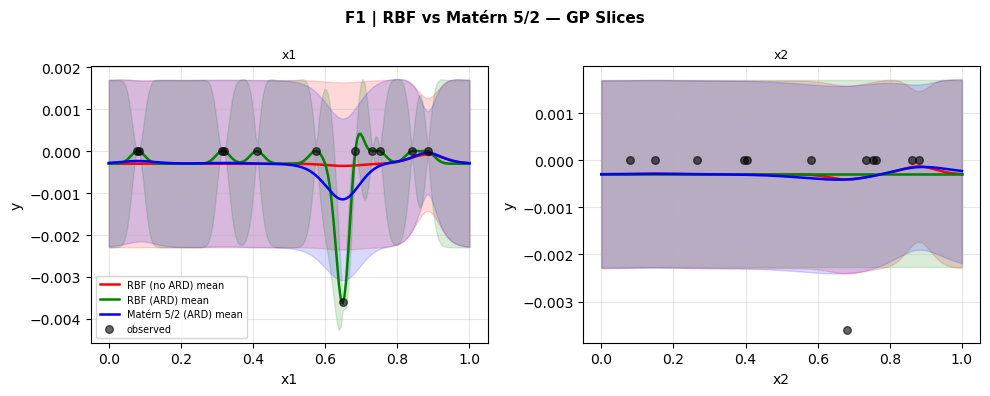

F2 | RBF (no ARD): RBF(length_scale=0.0316)
F2 | RBF (ARD): RBF(length_scale=[0.00194, 100])
F2 | Matérn 5/2 (ARD): Matern(length_scale=[0.0821, 0.0222], nu=2.5)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


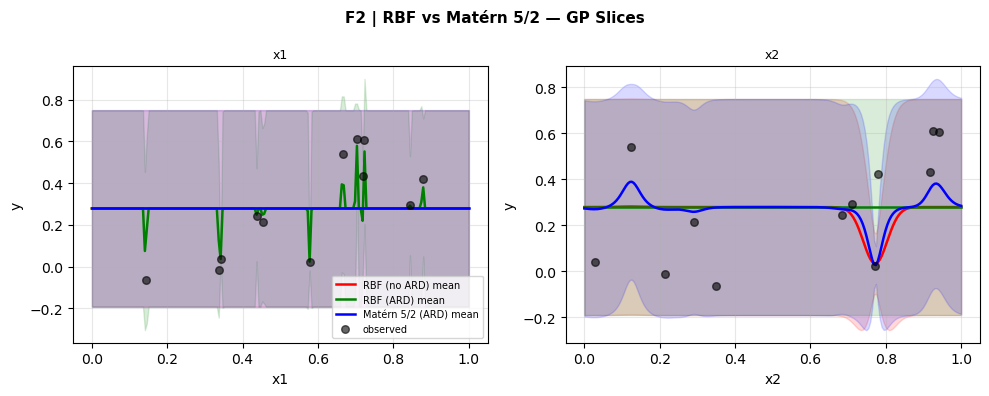

F3 | RBF (no ARD): RBF(length_scale=0.208)
F3 | RBF (ARD): RBF(length_scale=[100, 0.81, 0.066])
F3 | Matérn 5/2 (ARD): Matern(length_scale=[100, 1.23, 0.0718], nu=2.5)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


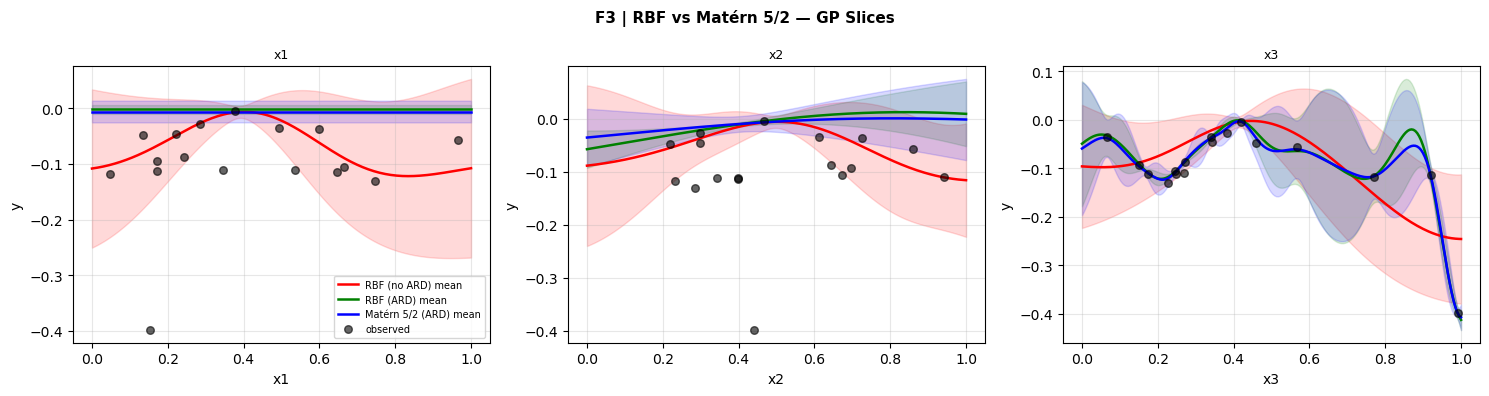

F4 | RBF (no ARD): RBF(length_scale=0.539)
F4 | RBF (ARD): RBF(length_scale=[0.568, 0.464, 0.614, 0.556])
F4 | Matérn 5/2 (ARD): Matern(length_scale=[0.761, 0.621, 0.81, 0.725], nu=2.5)


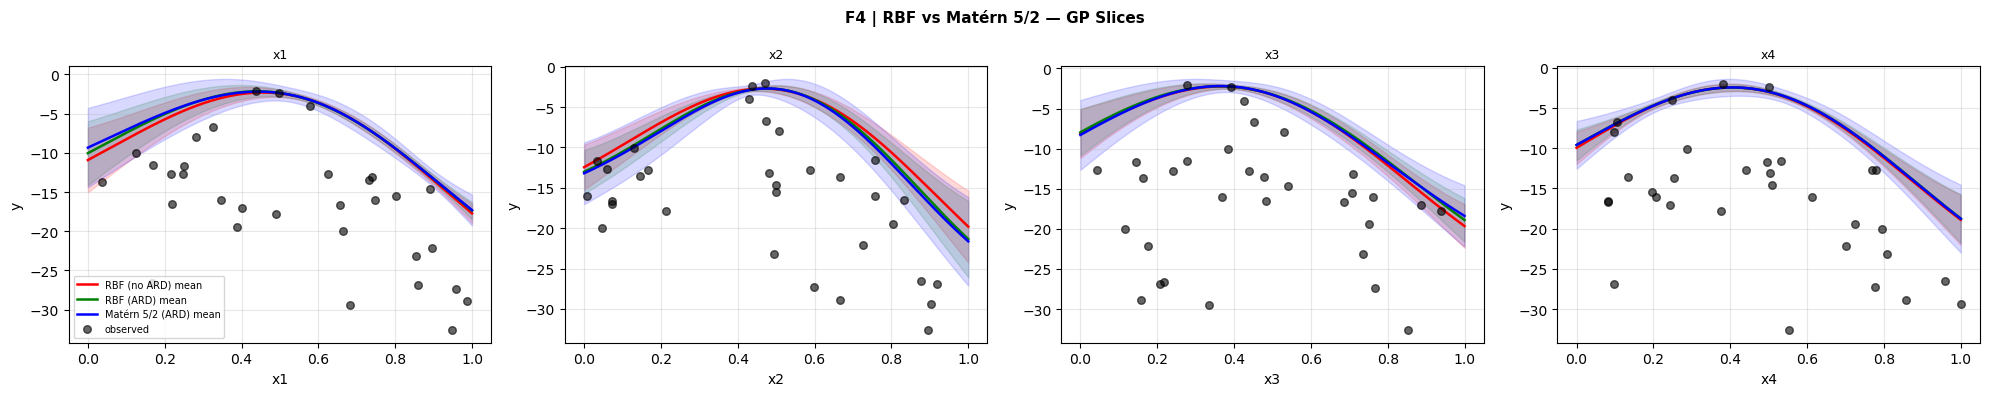

F5 | RBF (no ARD): RBF(length_scale=0.455)
F5 | RBF (ARD): RBF(length_scale=[0.102, 0.039, 38.2, 1.25])
F5 | Matérn 5/2 (ARD): Matern(length_scale=[100, 11.6, 0.587, 0.33], nu=2.5)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


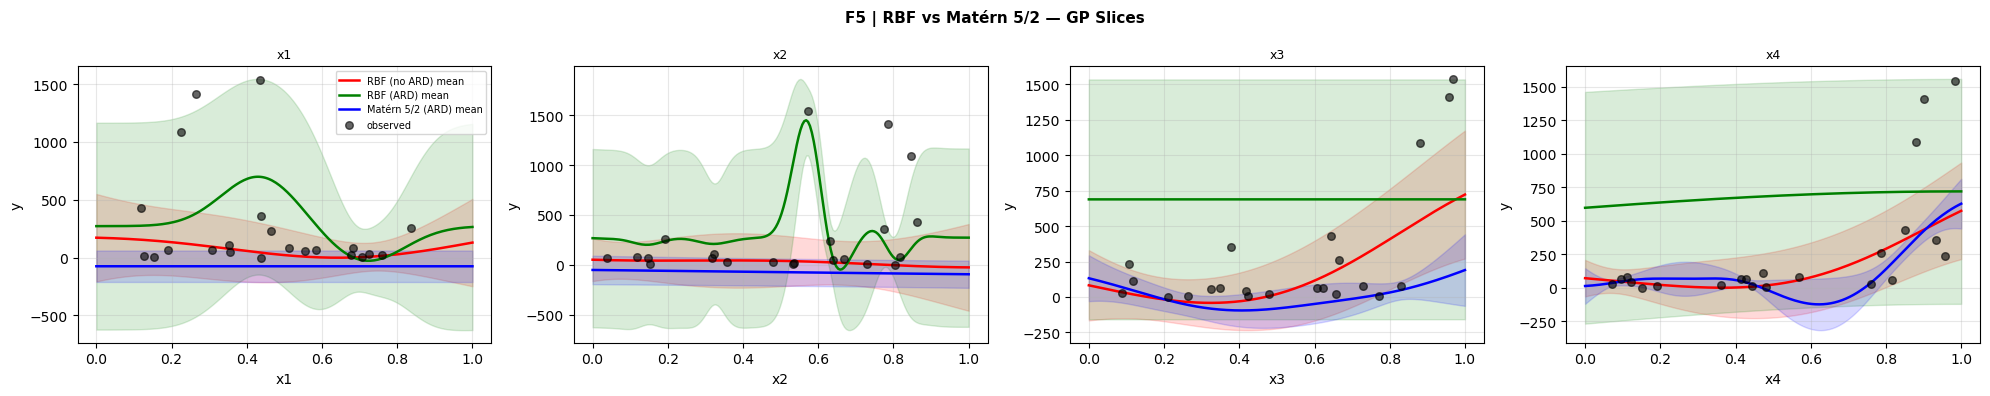

F6 | RBF (no ARD): RBF(length_scale=0.493)
F6 | RBF (ARD): RBF(length_scale=[0.349, 0.673, 0.669, 0.774, 0.652])
F6 | Matérn 5/2 (ARD): Matern(length_scale=[0.471, 0.872, 0.981, 0.955, 0.888], nu=2.5)


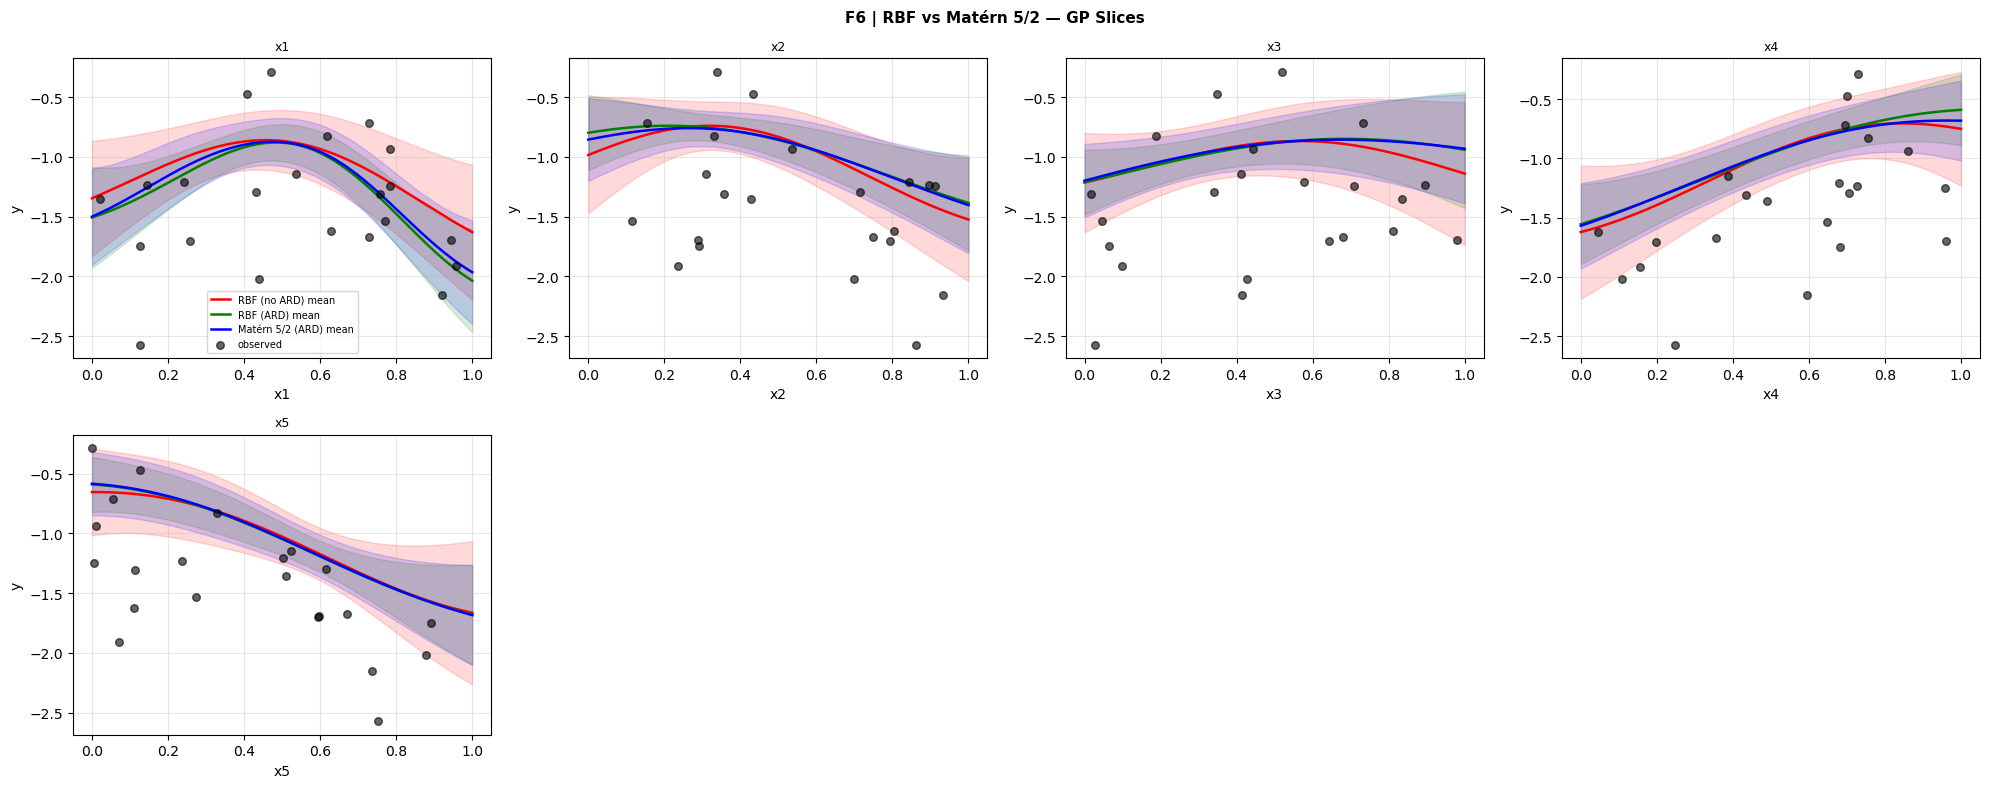

F7 | RBF (no ARD): RBF(length_scale=0.307)
F7 | RBF (ARD): RBF(length_scale=[0.132, 100, 0.498, 100, 0.382, 0.364])


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3

F7 | Matérn 5/2 (ARD): Matern(length_scale=[0.194, 100, 100, 0.264, 0.405, 100], nu=2.5)


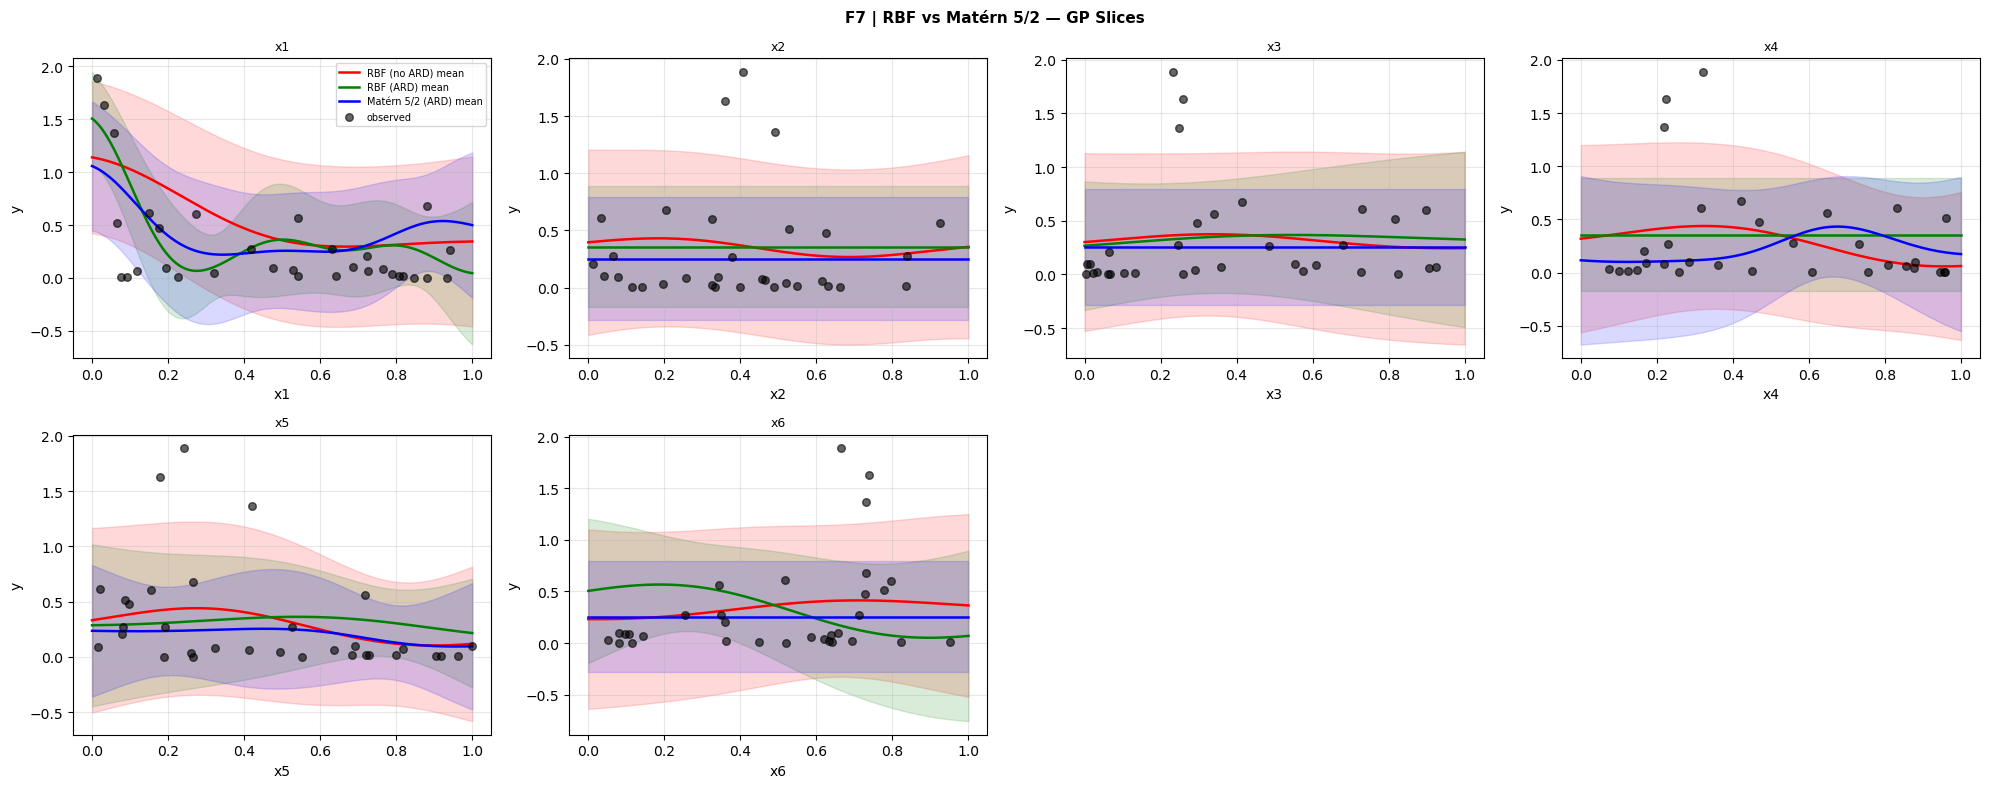

F8 | RBF (no ARD): RBF(length_scale=0.941)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


F8 | RBF (ARD): RBF(length_scale=[0.853, 1.06, 0.464, 1.82, 3.34, 100, 0.849, 8.07])


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


F8 | Matérn 5/2 (ARD): Matern(length_scale=[1.21, 1.74, 0.855, 2.17, 4.33, 100, 1.31, 100], nu=2.5)


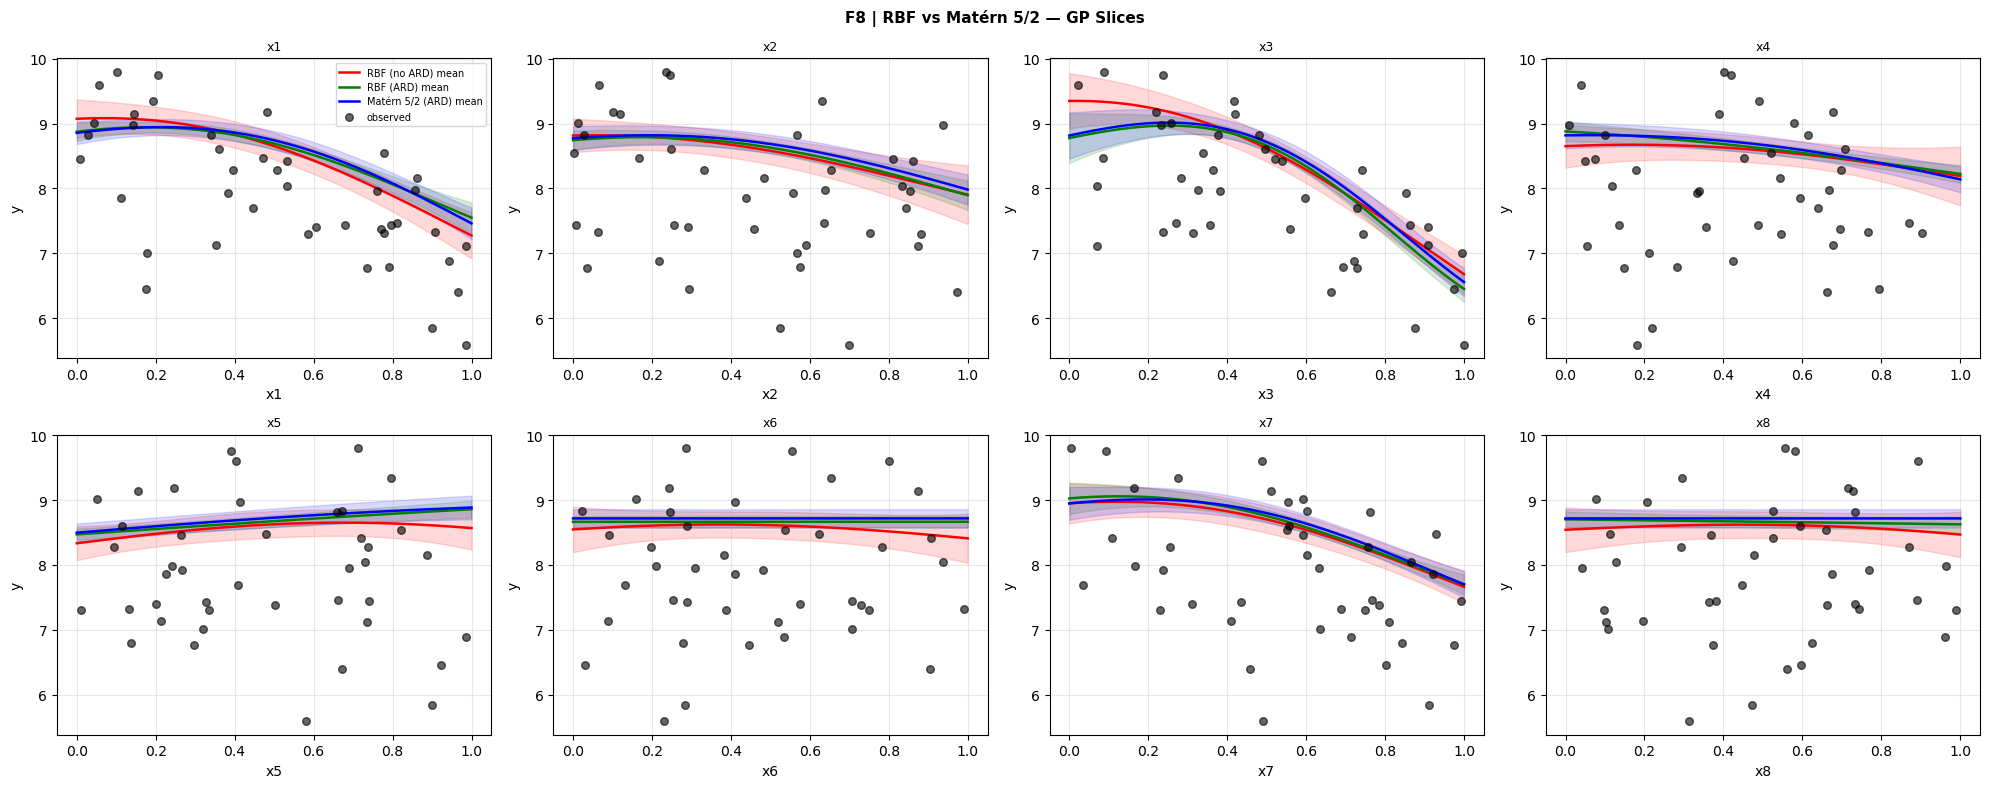

In [86]:
def compare_kernels(fn_num, n_candidates=5000):
    X = all_X[fn_num - 1].values
    Y = all_y[fn_num - 1].values
    n_dim = X.shape[1]
    dim_cols = all_X[fn_num - 1].columns.tolist()

    kernels = {
        'RBF (no ARD)':     RBF(length_scale=1.0, 
                                length_scale_bounds=(1e-3, 100.0)),
        'RBF (ARD)':        RBF(length_scale=np.ones(n_dim), 
                                length_scale_bounds=(1e-3, 100.0)),
        'Matérn 5/2 (ARD)': Matern(length_scale=np.ones(n_dim), 
                                    length_scale_bounds=(1e-3, 100.0), nu=2.5)
    }

    gps_local = {}
    for name, kernel in kernels.items():
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                       n_restarts_optimizer=max(5, 2*n_dim),
                                       normalize_y=True)
        gp.fit(X, Y)
        gps_local[name] = gp
        print(f'F{fn_num} | {name}: {gp.kernel_}')

    x_ref = np.mean(all_X[fn_num - 1].values, axis=0)  # central slice
    t = np.linspace(1e-6, 0.999999, 200)

    n_cols = min(4, n_dim)
    n_rows = int(np.ceil(n_dim / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5*n_cols, 4*n_rows),
                             squeeze=False)

    colors = {
        'RBF (no ARD)':     'red',
        'RBF (ARD)':        'green',
        'Matérn 5/2 (ARD)': 'blue'
    }

    for idx, col in enumerate(dim_cols):
        row, col_idx = divmod(idx, n_cols)
        ax = axes[row][col_idx]

        for name, gp in gps_local.items():  # ← fixed
            X_slice = np.tile(x_ref, (200, 1))
            X_slice[:, idx] = t
            mu, sigma = gp.predict(X_slice, return_std=True)
            c = colors[name]
            ax.plot(t, mu, color=c, linewidth=1.8, label=f'{name} mean')
            ax.fill_between(t, mu - 2*sigma, mu + 2*sigma,
                           alpha=0.15, color=c)

        ax.scatter(all_X[fn_num-1][col], all_y[fn_num-1],
                  color='black', s=30, zorder=5, alpha=0.6, label='observed')
        ax.set_xlabel(col)
        ax.set_ylabel('y')
        ax.set_title(f'{col}', fontsize=9)
        ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.legend(fontsize=7)

    for idx in range(n_dim, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r][c].set_visible(False)

    plt.suptitle(f'F{fn_num} | RBF vs Matérn 5/2 — GP Slices',
                fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()

for fn_num in range(1, 9):
    compare_kernels(fn_num)

In [87]:
fn_num = 7
print(df_best.loc[fn_num, 'submission'])
print(all_X[fn_num-1].columns.tolist())

0.002574-0.186295-0.947160-0.354646-0.297125-0.613900
['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
